In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import json
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did


In [2]:
with open('./data/cell_lineage.json', 'r', encoding='utf-8') as f:
    lineage_data = json.load(f)
terminal_nodes = []
intermediate_nodes = []
descendant_list_dict = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0 :
        terminal_nodes.append(lookup_name)
        for ancestor in ancestors:
            descendant_list_dict[ancestor].append(lookup_name)
    else:
        intermediate_nodes.append(lookup_name)
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)
print(len(intermediate_nodes), len(terminal_nodes))

1091 1092


In [3]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
cell_type_dict = {}
for node in terminal_nodes:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == node]
    if len(cur_cell_type_df) == 0:
        print(f"Warning: No cell type found for {node}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()].unique()
    if len(cur_lineage_types) == 0:
        # print(f"Warning: No valid cell type found for {node}")
        cell_type_dict[node] = "programmed_death"
        continue
    if len(cur_lineage_types) > 1:
        print(f"Warning: Multiple cell types found for {node}: {cur_lineage_types}")
    cur_type = cur_lineage_types[0]
    cell_type_dict[node] = cur_type

In [4]:
# one hot encoding of cell types, meaining each cell is assigned an one-hot vector corresponding to its type, this is used for the cell type prediction task
# rank the cell types by their frequency and assign an integer to each type
# programmed_death should be assigned as the last tpye since it's kind of special
cell_types = list(set(cell_type_dict.values()))
cell_types = [ct for ct in cell_types if ct != "programmed_death"]
cell_types = sorted(cell_types, key=lambda x: sum([1 for v in cell_type_dict.values() if v == x]), reverse=True)
cell_types.append("programmed_death")
cell_type_to_int = {ct: i for i, ct in enumerate(cell_types)}
cell_type_one_hot = {}
for node, ct in cell_type_dict.items():
    one_hot = np.zeros(len(cell_types))
    one_hot[cell_type_to_int[ct]] = 1
    cell_type_one_hot[node] = one_hot


In [5]:
# for internal node, the cell type is calculated as the sum of all its descendant terminal nodes'
# one-hot vectors and then normalized to get a distribution over cell types, this is used for the cell type prediction task
for node in intermediate_nodes:
    descendant_types = [cell_type_one_hot[desc] for desc in descendant_list_dict[node]]
    if len(descendant_types) == 0:
        print(f"Warning: No descendant types found for {node}")
        cell_type_one_hot[node] = np.zeros(len(cell_types))
        continue
    summed_types = np.sum(descendant_types, axis=0)
    normalized_types = summed_types / np.sum(summed_types)
    cell_type_one_hot[node] = normalized_types

In [6]:
protein_exp = pd.read_csv("./data/protein/aggregated_all/s3.csv", index_col=0).T
protein_exp = protein_exp.fillna(0)

In [7]:
protein_exp.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
AHR-1_SYS571,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_RW10757,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALR-1_SYS139,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
ALY-1_SYS619,0.0,0.0,0.0,33.29,153.49,146.94,182.34,109.03,60.47,77.66,...,65.56,66.3,85.99,42.42,41.02,0.0,0.0,0.0,0.0,0.0


In [8]:
# z-score normalization for each gene across all cells
# genes are rows and cells are columns, so we need to normalize across columns for each row
# but first, get rid of the genes that all all zero across all cells, since they are not informative at all and will cause problems for z-score normalization
protein_exp = protein_exp[~(protein_exp == 0).all(axis=1)]
protein_exp_zscore = protein_exp.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
protein_exp_zscore.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,...,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020
ALR-1_RW10757,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,...,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592
ALR-1_SYS139,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,...,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730
ALY-1_SYS619,-1.574885,-1.574885,-1.574885,-0.827994,1.868800,1.721845,2.516075,0.871300,-0.218186,0.167487,...,-0.103988,-0.087385,0.354377,-0.623154,-0.654564,-1.574885,-1.574885,-1.574885,-1.574885,-1.574885
ALY-2_SYS721,-1.899774,0.540951,0.282820,-0.438411,1.413989,-0.005436,0.402139,-0.413011,0.229067,-0.008389,...,0.939666,1.108012,1.089110,0.777817,-0.046784,0.071944,0.232612,0.918992,5.526953,5.323166


In [9]:
# save protein_exp_zscore to csv for latter use in "./data/protein/aggregated_all/s3_zscore.csv"
protein_exp_zscore.to_csv("./data/protein/aggregated_all/s3_zscore.csv")

In [10]:
# set up training data
# X will be the value of protein_exp_zscore
# y will be the cell type one-hot vector
X = protein_exp_zscore.values.T
y = np.array([cell_type_one_hot[map_names(node)] for node in protein_exp_zscore.columns])
print(X.shape, y.shape)

(1204, 210) (1204, 18)


In [11]:
# for each sample, there is also consideration given to the difference between hard labels and soft mixed labels
# it should be the inverse of how many descendant terminal nodes it has, since the more descendant terminal nodes it has, the softer the label is, and the less weight it should have in the training process
sample_weights = np.array([1/len(descendant_list_dict[map_names(node)]) if len(descendant_list_dict[map_names(node)]) > 0 else 1 for node in protein_exp_zscore.columns])
print(sample_weights.shape)

(1204,)


Terminal (hard): 494  |  Intermediate (soft): 710


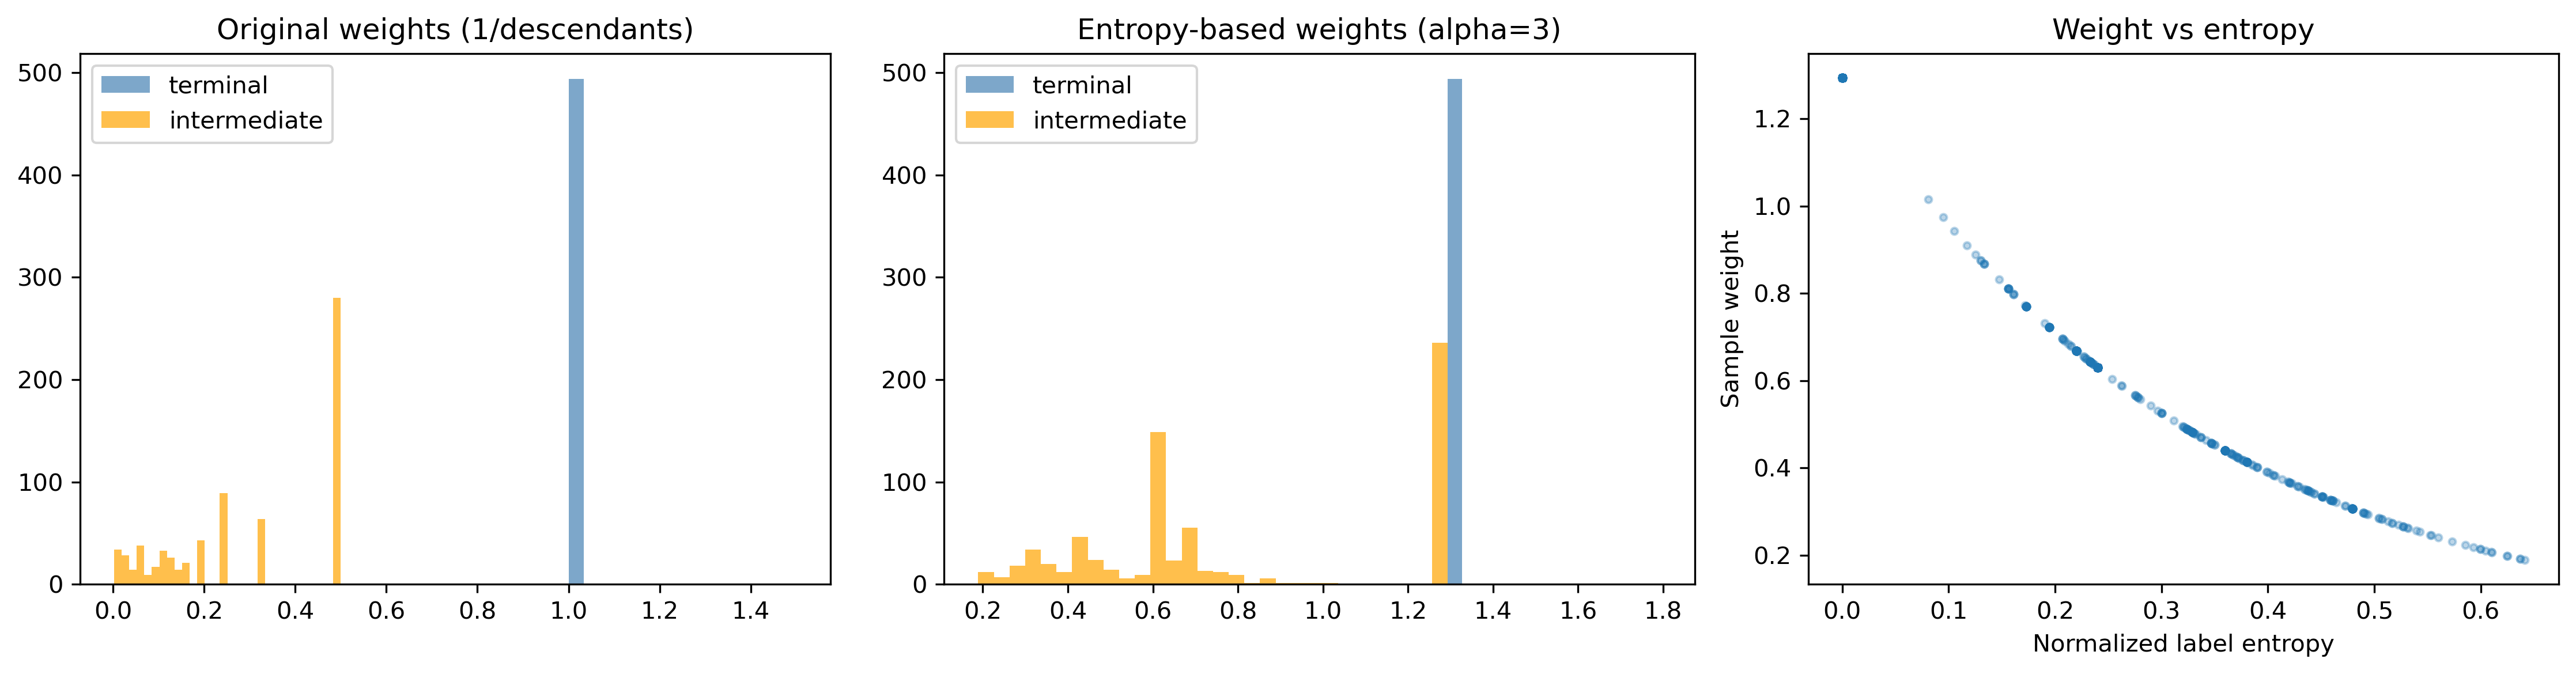

Hard nodes  – mean_w=1.294, max_w=1.294
Soft nodes  – mean_w=0.796, max_w=1.294


In [12]:

# === Improved Sample Weights: Entropy-Based ===
# 
# The original 1/num_descendants scheme is a proxy for label hardness, but
# entropy of the soft label directly measures uncertainty regardless of tree depth.
# Hard (terminal) nodes have one-hot labels → H=0 → weight≈1.
# Soft (intermediate) nodes have mixed labels → H>0 → weight<1.

def entropy_based_weights(y_soft, alpha=3.0):
    """
    alpha: sharpness. Higher alpha → harder labels get even more relative weight.
    Returns weights normalized so mean=1.
    """
    y_clipped = np.clip(y_soft, 1e-10, 1.0)
    entropies = -np.sum(y_clipped * np.log(y_clipped), axis=1)
    max_ent = np.log(y_soft.shape[1])
    norm_ent = entropies / max_ent          # 0=hard/one-hot, 1=uniform
    weights = np.exp(-alpha * norm_ent)
    return (weights / weights.mean()).astype(np.float32)

sample_weights_v2 = entropy_based_weights(y, alpha=3.0)

# Mask for terminal (hard-label) vs intermediate (soft-label) nodes
terminal_mask = np.array([
    len(descendant_list_dict[map_names(node)]) == 0
    for node in protein_exp_zscore.columns
])
print(f"Terminal (hard): {terminal_mask.sum()}  |  Intermediate (soft): {(~terminal_mask).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sample_weights[terminal_mask], bins=30, alpha=0.7, color='steelblue', label='terminal')
axes[0].hist(sample_weights[~terminal_mask], bins=30, alpha=0.7, color='orange', label='intermediate')
axes[0].set_title('Original weights (1/descendants)')
axes[0].legend()

axes[1].hist(sample_weights_v2[terminal_mask], bins=30, alpha=0.7, color='steelblue', label='terminal')
axes[1].hist(sample_weights_v2[~terminal_mask], bins=30, alpha=0.7, color='orange', label='intermediate')
axes[1].set_title('Entropy-based weights (alpha=3)')
axes[1].legend()

norm_ent_all = -np.sum(np.clip(y, 1e-10,1) * np.log(np.clip(y, 1e-10,1)), axis=1) / np.log(y.shape[1])
axes[2].scatter(norm_ent_all, sample_weights_v2, alpha=0.3, s=8)
axes[2].set_xlabel('Normalized label entropy')
axes[2].set_ylabel('Sample weight')
axes[2].set_title('Weight vs entropy')

plt.tight_layout()
plt.show()

print(f"Hard nodes  – mean_w={sample_weights_v2[terminal_mask].mean():.3f}, max_w={sample_weights_v2[terminal_mask].max():.3f}")
print(f"Soft nodes  – mean_w={sample_weights_v2[~terminal_mask].mean():.3f}, max_w={sample_weights_v2[~terminal_mask].max():.3f}")


In [32]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ─────────────────────────────────────────────────────────────────
# Model 1 – SparseGateClassifier (Phase 1: feature selection)
#
# A learnable gate (sigmoid of free parameters) multiplies each
# input feature. L1 regularisation on the gate values drives
# unimportant features toward zero, giving us feature importance
# scores after training.
# ─────────────────────────────────────────────────────────────────
class SparseGateClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_dims=(128, 64), dropout=0.3):
        super().__init__()
        # One learnable scalar per input feature
        self.gate_logits = nn.Parameter(torch.zeros(n_features))

        layers = []
        in_dim = n_features
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_logits)
        h = self.backbone(x * gates)
        return self.head(h), h                 # (logits, embedding)

    def gate_l1(self):
        """L1 loss on gate values – encourages sparsity."""
        return torch.sigmoid(self.gate_logits).sum()

    def feature_importance(self):
        return torch.sigmoid(self.gate_logits).detach().cpu().numpy()


# ─────────────────────────────────────────────────────────────────
# Model 2 – FocusedClassifier (Phase 2: final model on selected features)
#
# Smaller, cleaner network trained on the top-k features only.
# The penultimate-layer embedding is exposed for downstream
# pairwise-distance analysis.
# ─────────────────────────────────────────────────────────────────
class FocusedClassifier(nn.Module):
    def __init__(self, n_selected, n_classes, hidden_dims=(64, 32), dropout=0.2):
        super().__init__()
        layers = []
        in_dim = n_selected
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        h = self.backbone(x)
        return self.head(h), h                 # (logits, embedding)

print("Models defined: SparseGateClassifier, FocusedClassifier")


Models defined: SparseGateClassifier, FocusedClassifier


In [33]:

# ─── Training utilities ───────────────────────────────────────────

def soft_cross_entropy(logits, soft_targets, weights=None):
    """
    Cross-entropy with soft/distributional targets.
    Optionally applies per-sample weights (higher = more influence on loss).
    """
    log_p = F.log_softmax(logits, dim=-1)
    per_sample = -(soft_targets * log_p).sum(dim=-1)
    if weights is not None:
        per_sample = per_sample * weights
    return per_sample.mean()


def train_epoch(model, loader, optimizer, device, l1_lambda=0.0):
    model.train()
    total = 0.0
    for xb, yb, wb in loader:
        xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = soft_cross_entropy(logits, yb, wb)
        if l1_lambda > 0 and hasattr(model, 'gate_l1'):
            loss = loss + l1_lambda * model.gate_l1()
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_accuracy(model, X_tensor, y_tensor, mask, device):
    """Accuracy on the subset of samples indicated by boolean mask."""
    model.eval()
    logits, _ = model(X_tensor.to(device))
    preds   = logits.argmax(dim=-1).cpu().numpy()
    targets = y_tensor.argmax(dim=-1).cpu().numpy()
    m = mask.numpy() if isinstance(mask, torch.Tensor) else mask
    return (preds[m] == targets[m]).mean()


print("Training utilities ready.")


Training utilities ready.


Device: cuda


Phase 1:   0%|          | 0/500 [00:00<?, ?it/s]

Phase 1:  21%|██        | 105/500 [00:02<00:08, 45.20it/s]

  ep  100 | loss=0.6561 | hard-acc=1.000 | gates>0.3: 210


Phase 1:  41%|████      | 205/500 [00:04<00:06, 46.73it/s]

...

  ep  300 | loss=0.4632 | hard-acc=1.000 | gates>0.3: 65


Phase 1:  81%|████████  | 405/500 [00:08<00:02, 46.35it/s]

  ep  400 | loss=0.4455 | hard-acc=1.000 | gates>0.3: 47


Phase 1: 100%|██████████| 500/500 [00:10<00:00, 46.04it/s]


  ep  500 | loss=0.4436 | hard-acc=1.000 | gates>0.3: 45


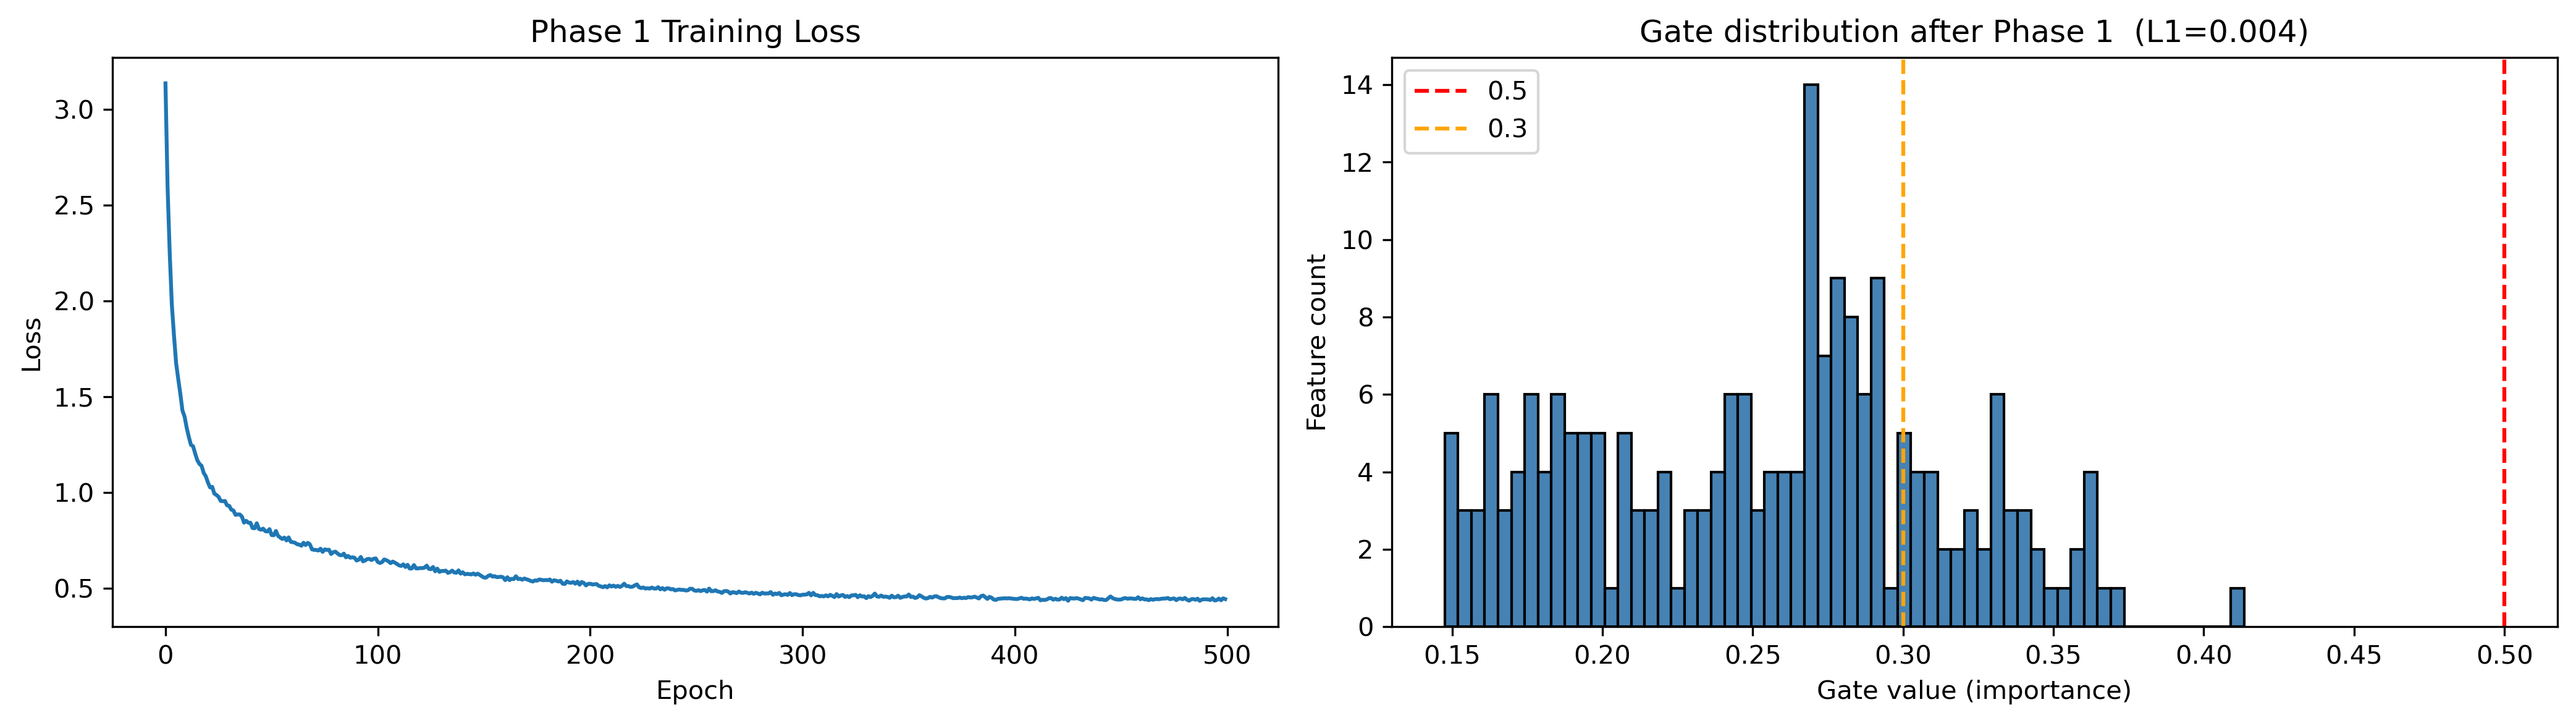


Gates > 0.5: 0
Gates > 0.3: 45
Gates > 0.1: 210


In [34]:

# ─── Phase 1: Train SparseGateClassifier to identify important features ──────
#
# L1_LAMBDA controls sparsity:
#   too small → all features kept (poor selection)
#   too large  → too few features survive (underfitting)
# Aim: ≈10-20 features with gate > 0.3 after training.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

X_t = torch.FloatTensor(X)
y_t = torch.FloatTensor(y)
w_t = torch.FloatTensor(sample_weights_v2)
term_t = torch.BoolTensor(terminal_mask)

dataset = TensorDataset(X_t, y_t, w_t)
loader  = DataLoader(dataset, batch_size=128, shuffle=True)

L1_LAMBDA  = 0.004
N_EPOCHS_P1 = 500

torch.manual_seed(42)
model_sparse = SparseGateClassifier(
    n_features   = X.shape[1],
    n_classes    = y.shape[1],
    hidden_dims  = (128, 64),
    dropout      = 0.3,
).to(device)

opt1   = optim.Adam(model_sparse.parameters(), lr=1e-3, weight_decay=1e-4)
sched1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=N_EPOCHS_P1)

losses_p1 = []
checkpoints = []

for epoch in tqdm(range(N_EPOCHS_P1), desc="Phase 1"):
    loss = train_epoch(model_sparse, loader, opt1, device, l1_lambda=L1_LAMBDA)
    sched1.step()
    losses_p1.append(loss)
    if (epoch + 1) % 100 == 0:
        acc = eval_accuracy(model_sparse, X_t, y_t, term_t, device)
        gates_above = (model_sparse.feature_importance() > 0.3).sum()
        checkpoints.append((epoch+1, loss, acc, gates_above))
        tqdm.write(f"  ep {epoch+1:4d} | loss={loss:.4f} | hard-acc={acc:.3f} | gates>0.3: {gates_above}")

# ── Training summary ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(losses_p1)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Phase 1 Training Loss')

gate_vals = model_sparse.feature_importance()
ax2.hist(gate_vals, bins=60, edgecolor='black', color='steelblue')
ax2.axvline(0.5, color='red',    linestyle='--', label='0.5')
ax2.axvline(0.3, color='orange', linestyle='--', label='0.3')
ax2.set_xlabel('Gate value (importance)'); ax2.set_ylabel('Feature count')
ax2.set_title(f'Gate distribution after Phase 1  (L1={L1_LAMBDA})')
ax2.legend()
plt.tight_layout(); plt.show()

print(f"\nGates > 0.5: {(gate_vals > 0.5).sum()}")
print(f"Gates > 0.3: {(gate_vals > 0.3).sum()}")
print(f"Gates > 0.1: {(gate_vals > 0.1).sum()}")


Rank  Feature                                Gate
--------------------------------------------------
   1   HLH-2_SYS1049                        0.4134
   2   CEH-27_SYS89                         0.3729
   3   CEH-45_SYS634                        0.3650
   4   PHA-4_RW10425                        0.3623
   5   ALY-2_SYS721                         0.3623
   6   CEH-51_SYS397                        0.3607
   7   DUXL-1_SYS431                        0.3604
   8   CES-2_SYS443                         0.3571
   9   EGRH-1_SYS444                        0.3564
  10   SPR-4_SYS475                         0.3555
  11   NHR-25_RW10348                       0.3485
  12   MEP-1_SYS83                          0.3458
  13   ALY-1_SYS619                         0.3452
  14   NFYC-1_SYS678                        0.3393
  15   SOX-2_SYS516                         0.3386


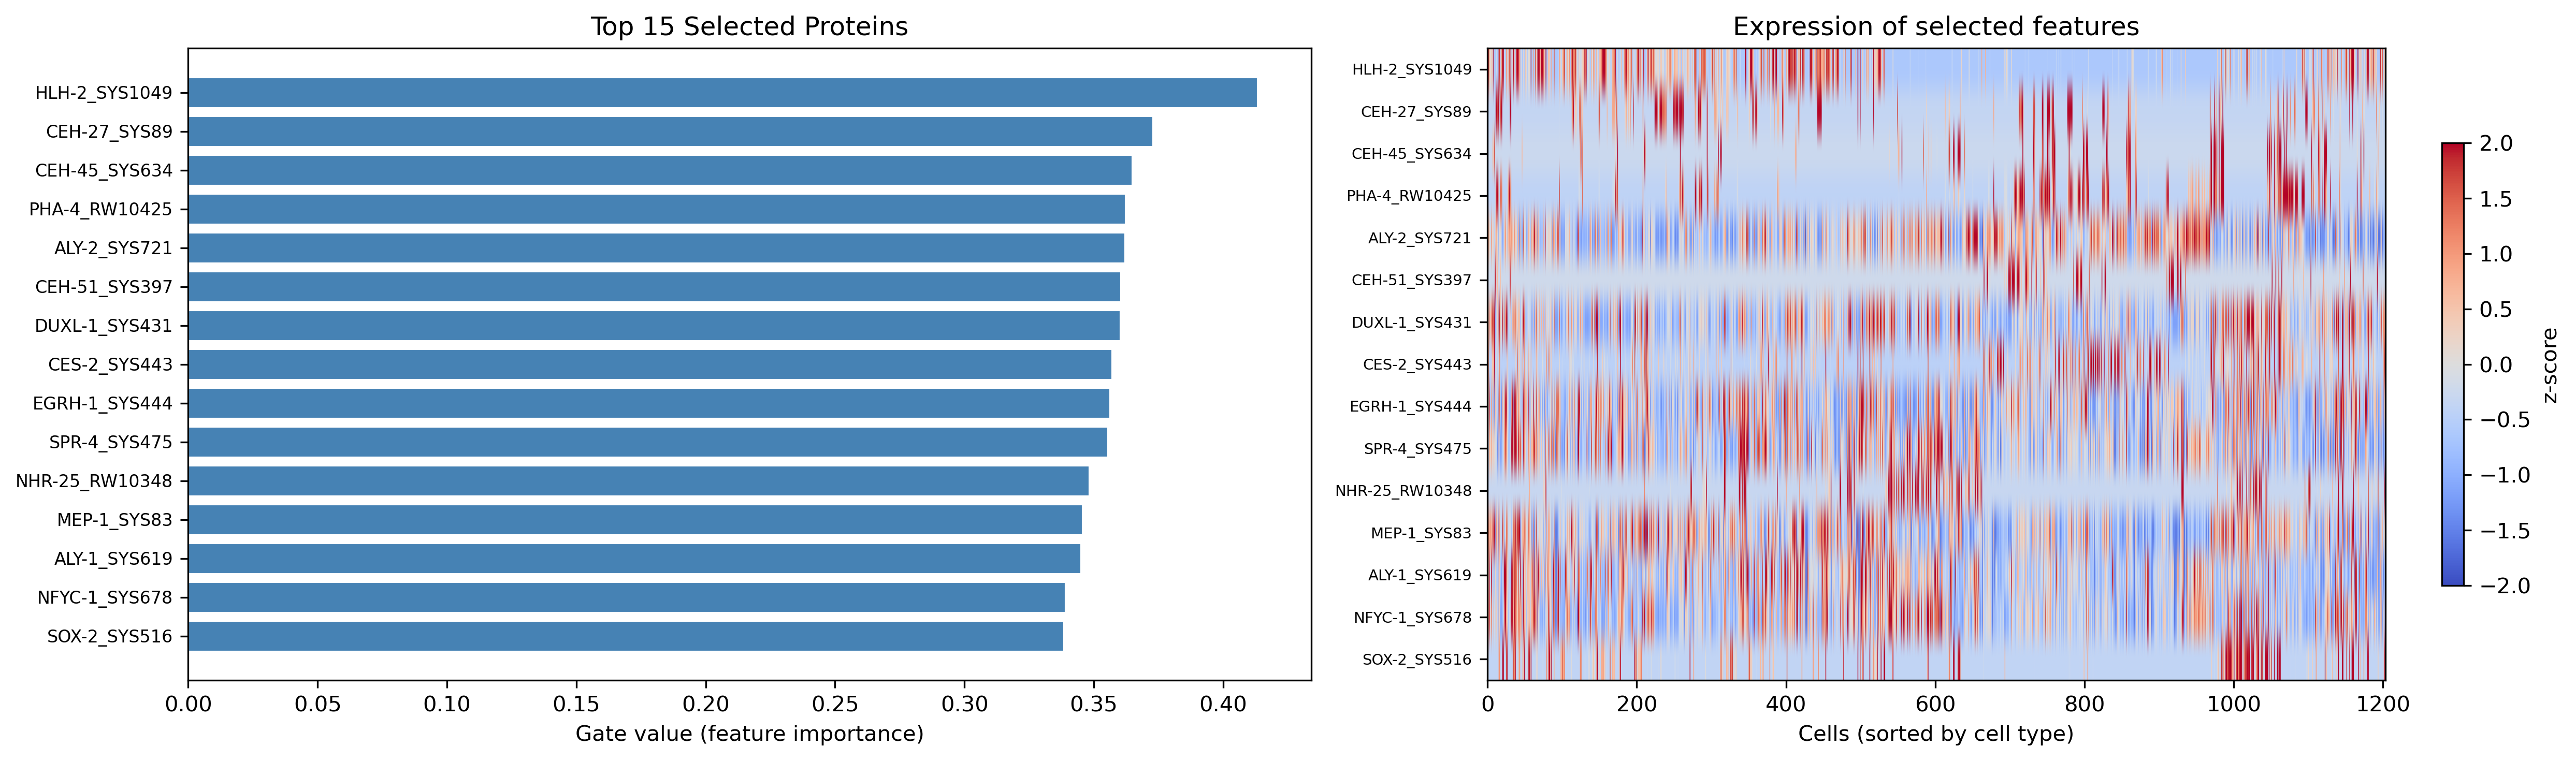

In [35]:

# ─── Feature Selection: pick top-N_SELECT features by gate value ──────────────
#
# Adjust N_SELECT to taste; 12-15 is a reasonable starting point.
# If gate distribution is bimodal you can also threshold at 0.3 or 0.5.

N_SELECT = 15

feature_names = np.array(protein_exp_zscore.index.tolist())
gate_vals     = model_sparse.feature_importance()

top_idx      = np.argsort(gate_vals)[::-1][:N_SELECT]
top_features = feature_names[top_idx]
top_gates    = gate_vals[top_idx]

print(f"{'Rank':>4}  {'Feature':35s}  {'Gate':>6}")
print("-" * 50)
for rank, (name, g) in enumerate(zip(top_features, top_gates), 1):
    print(f"  {rank:2d}   {name:35s}  {g:.4f}")

# ── Visualisations ──
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Bar chart of importance
ax = axes[0]
ax.barh(range(N_SELECT), top_gates[::-1], color='steelblue', edgecolor='white')
ax.set_yticks(range(N_SELECT))
ax.set_yticklabels(top_features[::-1], fontsize=8)
ax.set_xlabel('Gate value (feature importance)')
ax.set_title(f'Top {N_SELECT} Selected Proteins')

# Heatmap: selected features × cells, sorted by true cell type
ax = axes[1]
cell_type_order = np.argsort(y.argmax(axis=1))
X_sel_plot = X[:, top_idx][cell_type_order]
im = ax.imshow(X_sel_plot.T, aspect='auto', cmap='coolwarm', vmin=-2, vmax=2)
ax.set_yticks(range(N_SELECT))
ax.set_yticklabels(top_features, fontsize=7)
ax.set_xlabel('Cells (sorted by cell type)')
ax.set_title('Expression of selected features')
plt.colorbar(im, ax=ax, label='z-score', shrink=0.7)

plt.tight_layout()
plt.show()


Phase 2:  17%|█▋        | 104/600 [00:03<00:15, 31.48it/s]

  ep  100 | loss=0.8262 | hard-acc=0.860


Phase 2:  34%|███▍      | 204/600 [00:06<00:12, 31.23it/s]

  ep  200 | loss=0.7529 | hard-acc=0.907


Phase 2:  51%|█████     | 304/600 [00:09<00:09, 31.19it/s]

...

  ep  400 | loss=0.6972 | hard-acc=0.951


Phase 2:  84%|████████▍ | 504/600 [00:16<00:03, 30.89it/s]

  ep  500 | loss=0.6690 | hard-acc=0.955


Phase 2: 100%|██████████| 600/600 [00:19<00:00, 31.29it/s]


  ep  600 | loss=0.6909 | hard-acc=0.957


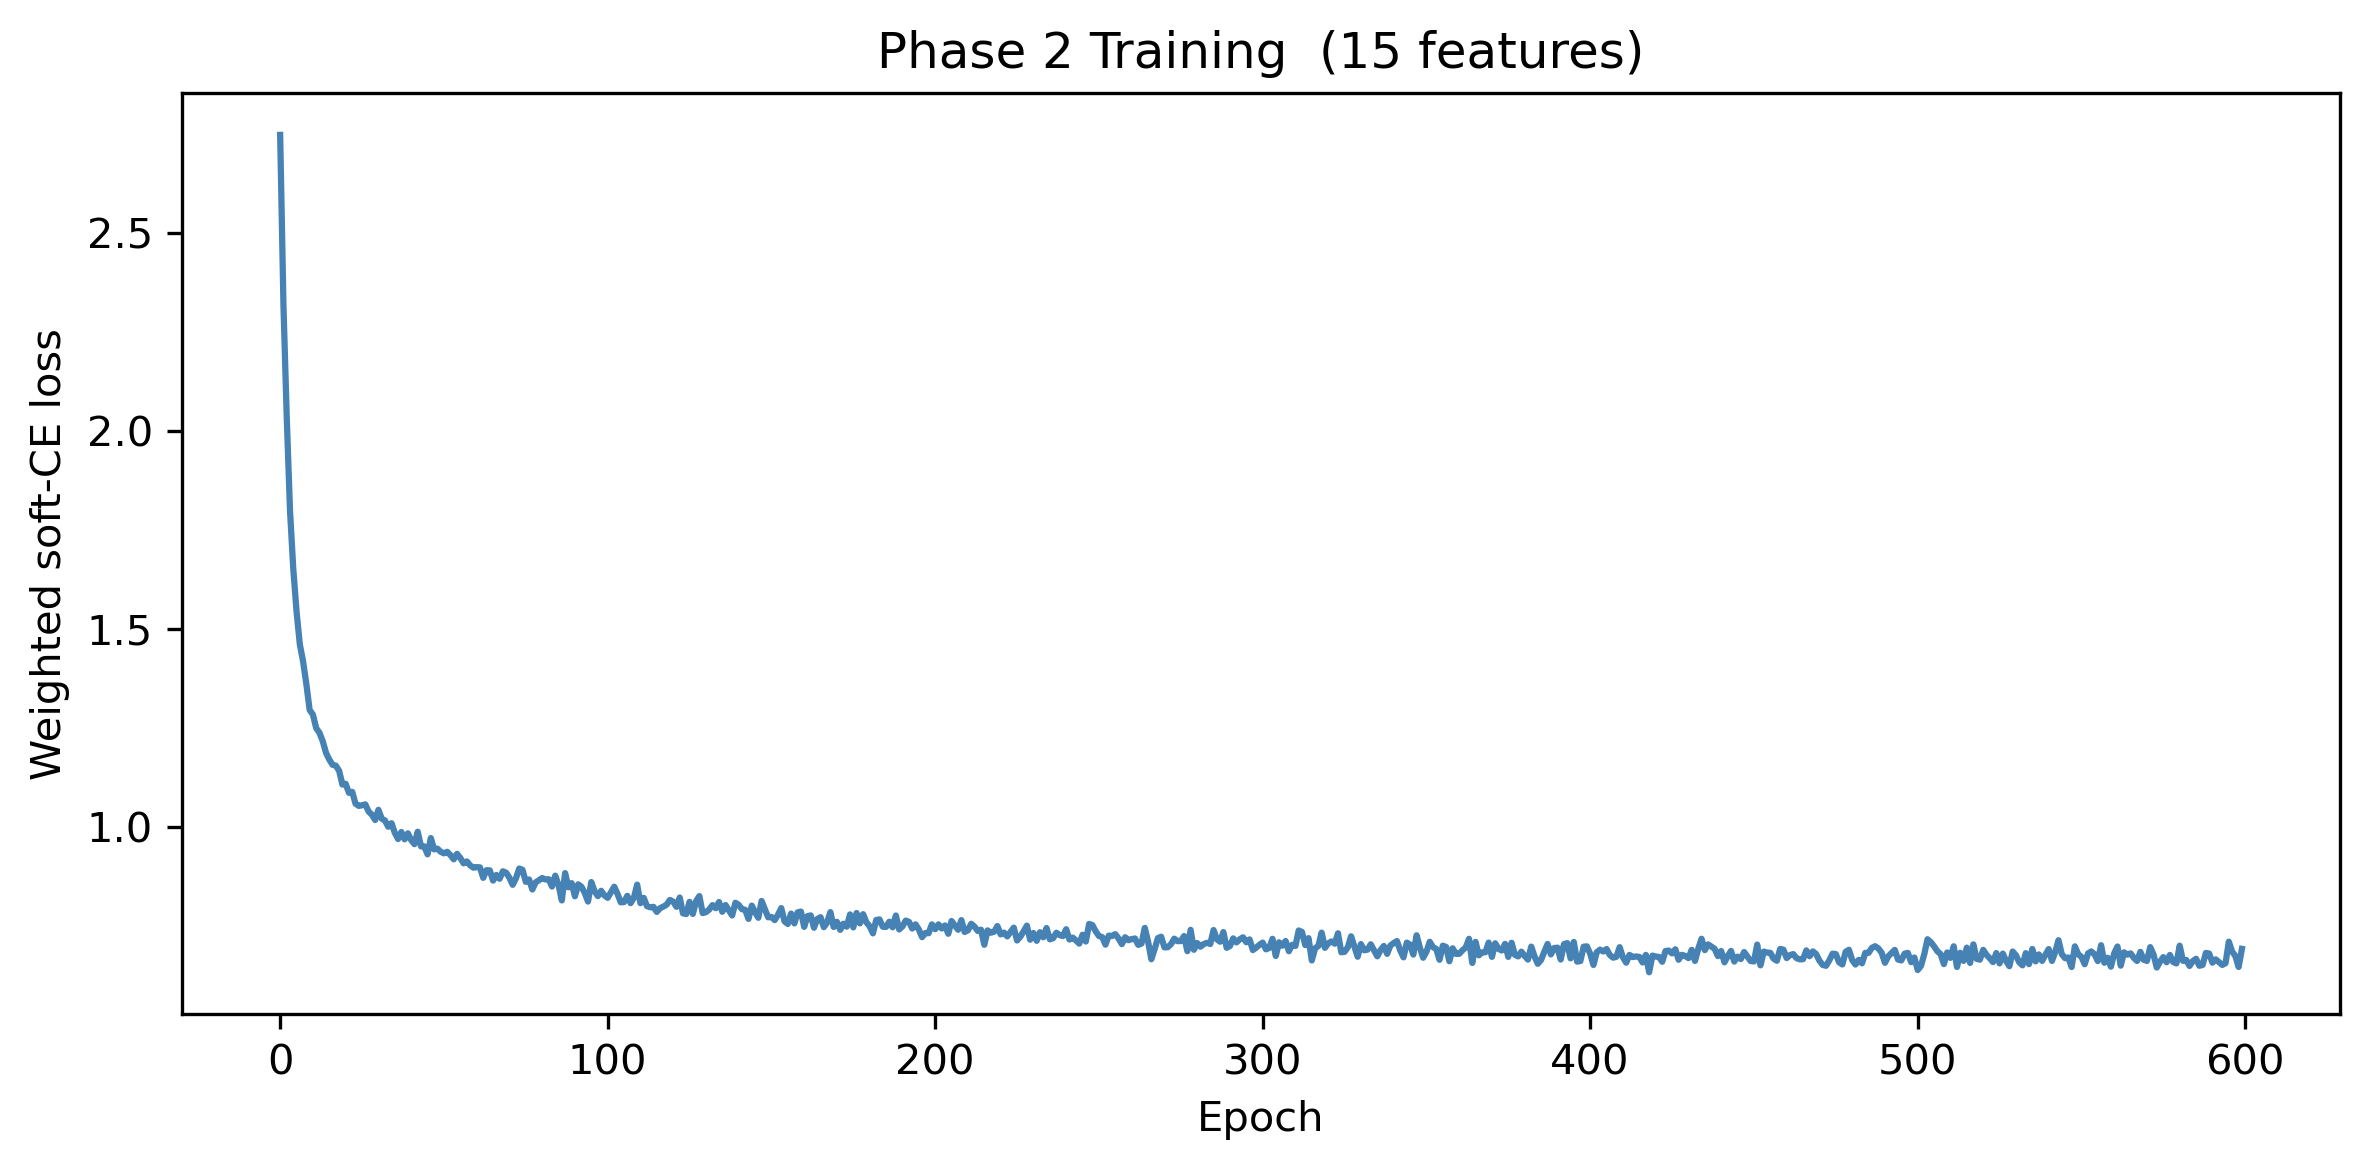


Final hard-label (terminal) accuracy : 0.9575
Final all-sample accuracy            : 0.8248


In [36]:

# ─── Phase 2: Train FocusedClassifier on the N_SELECT selected features ───────
#
# Smaller, clean model. No L1 needed — features are already fixed.
# The 32-dim penultimate layer will serve as the distance-metric embedding.

X_sel   = X[:, top_idx].astype(np.float32)
X_sel_t = torch.FloatTensor(X_sel)

dataset_sel = TensorDataset(X_sel_t, y_t, w_t)
loader_sel  = DataLoader(dataset_sel, batch_size=64, shuffle=True)

N_EPOCHS_P2 = 600

torch.manual_seed(42)
model_final = FocusedClassifier(
    n_selected  = N_SELECT,
    n_classes   = y.shape[1],
    hidden_dims = (64, 32),
    dropout     = 0.2,
).to(device)

opt2   = optim.Adam(model_final.parameters(), lr=1e-3, weight_decay=1e-4)
sched2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=N_EPOCHS_P2)

losses_p2 = []

for epoch in tqdm(range(N_EPOCHS_P2), desc="Phase 2"):
    loss = train_epoch(model_final, loader_sel, opt2, device, l1_lambda=0.0)
    sched2.step()
    losses_p2.append(loss)
    if (epoch + 1) % 100 == 0:
        acc = eval_accuracy(model_final, X_sel_t, y_t, term_t, device)
        tqdm.write(f"  ep {epoch+1:4d} | loss={loss:.4f} | hard-acc={acc:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_p2, color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted soft-CE loss')
ax.set_title(f'Phase 2 Training  ({N_SELECT} features)')
plt.tight_layout(); plt.show()

final_acc = eval_accuracy(model_final, X_sel_t, y_t, term_t, device)
all_acc   = eval_accuracy(model_final, X_sel_t, y_t, np.ones(len(y), dtype=bool), device)
print(f"\nFinal hard-label (terminal) accuracy : {final_acc:.4f}")
print(f"Final all-sample accuracy            : {all_acc:.4f}")


Hard-label accuracy  : 0.9575
All-sample accuracy  : 0.8248

Cell type                         Acc  n
---------------------------------------------
  socket                        1.000  18
  muscle                        1.000  110
  other                         1.000  9
  hypoderm                      1.000  51
  rectal                        1.000  2
  tail                          1.000  2
  valve                         1.000  8
  intestine                     1.000  2
  mesoderm                      1.000  1
  repro                         1.000  2
  neuron                        0.982  167
  programmed_death              0.878  74
  epithelium                    0.846  13
  sheath                        0.818  22
  marginal                      0.778  9
  excretory                     0.750  4


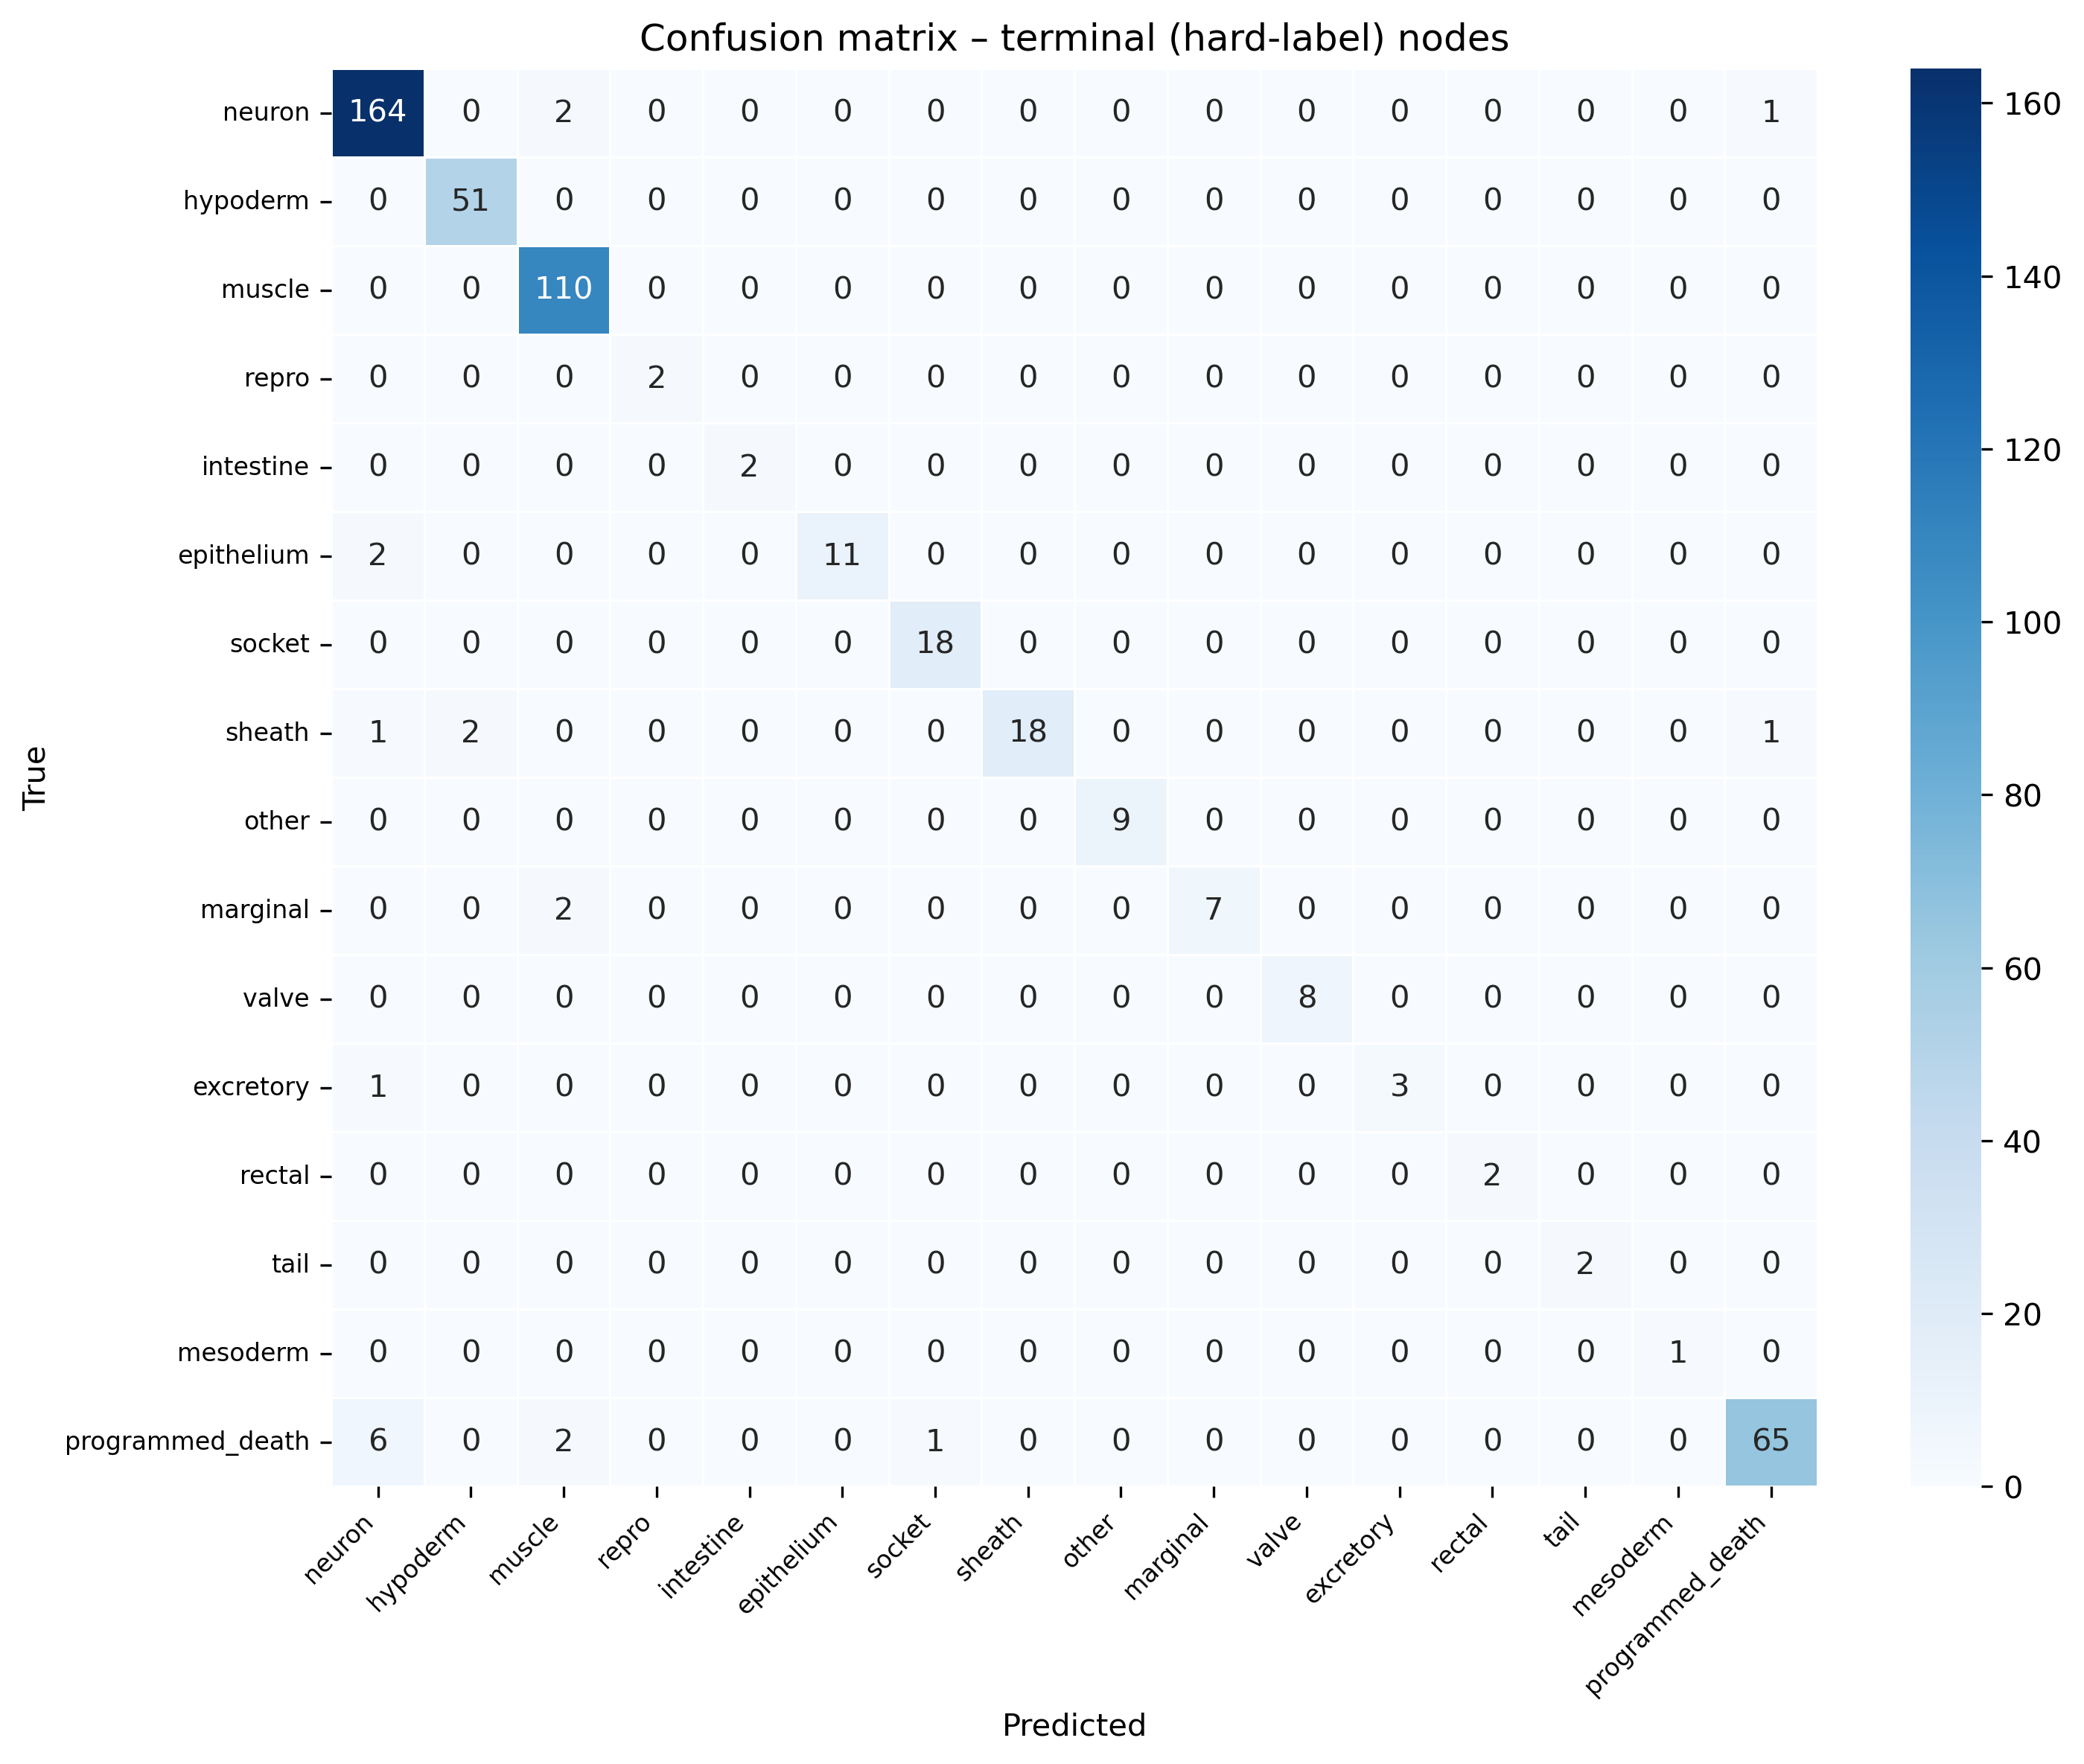

In [37]:

# ─── Evaluation: confusion matrix on hard-label (terminal) nodes ──────────────

model_final.eval()
with torch.no_grad():
    logits_all, _ = model_final(X_sel_t.to(device))
    probs_all = F.softmax(logits_all, dim=-1).cpu().numpy()

preds_all   = probs_all.argmax(axis=1)
targets_all = y.argmax(axis=1)

term_preds   = preds_all[terminal_mask]
term_targets = targets_all[terminal_mask]

print(f"Hard-label accuracy  : {(term_preds == term_targets).mean():.4f}")
print(f"All-sample accuracy  : {(preds_all == targets_all).mean():.4f}\n")

# Per-cell-type breakdown
per_type = defaultdict(list)
for p, t in zip(term_preds, term_targets):
    per_type[cell_types[t]].append(p == t)

print(f"{'Cell type':30s}  {'Acc':>5}  n")
print("-" * 45)
for ct, vals in sorted(per_type.items(), key=lambda x: -np.mean(x[1])):
    print(f"  {ct:28s}  {np.mean(vals):.3f}  {len(vals)}")

# Confusion matrix
present_types = sorted(np.unique(term_targets).tolist())
conf = np.zeros((len(present_types), len(present_types)), dtype=int)
t2i  = {t: i for i, t in enumerate(present_types)}
for p, t in zip(term_preds, term_targets):
    if p in t2i:
        conf[t2i[t], t2i[p]] += 1

ct_labels = [cell_types[i] for i in present_types]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=ct_labels, yticklabels=ct_labels, ax=ax,
            linewidths=0.3)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix – terminal (hard-label) nodes')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


Embedding matrix: (1204, 32)  (n_cells × embed_dim)
Cell names: ['ABa' 'ABal' 'ABala' 'ABalaa' 'ABalaaa'] ...


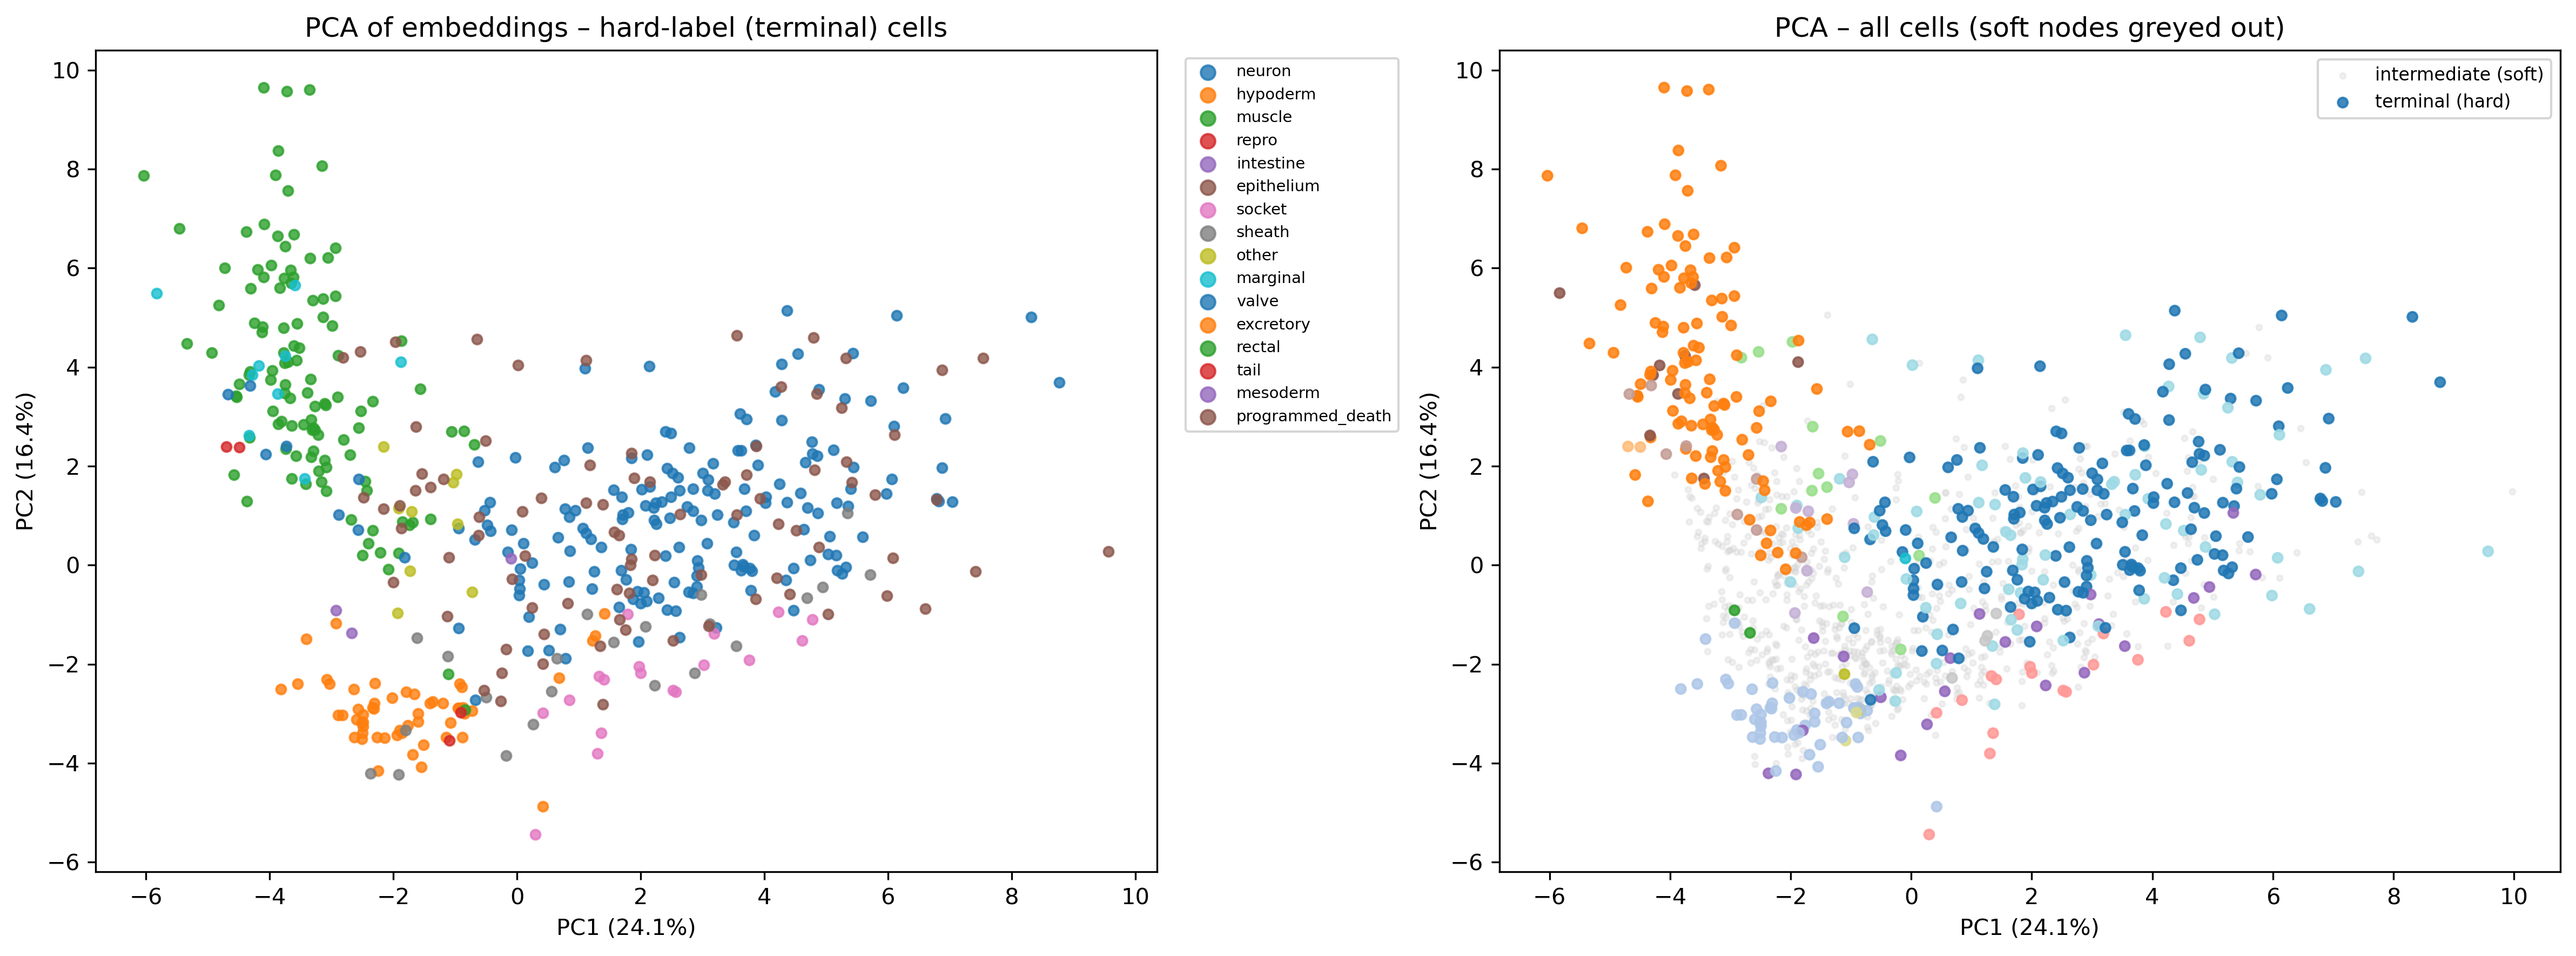

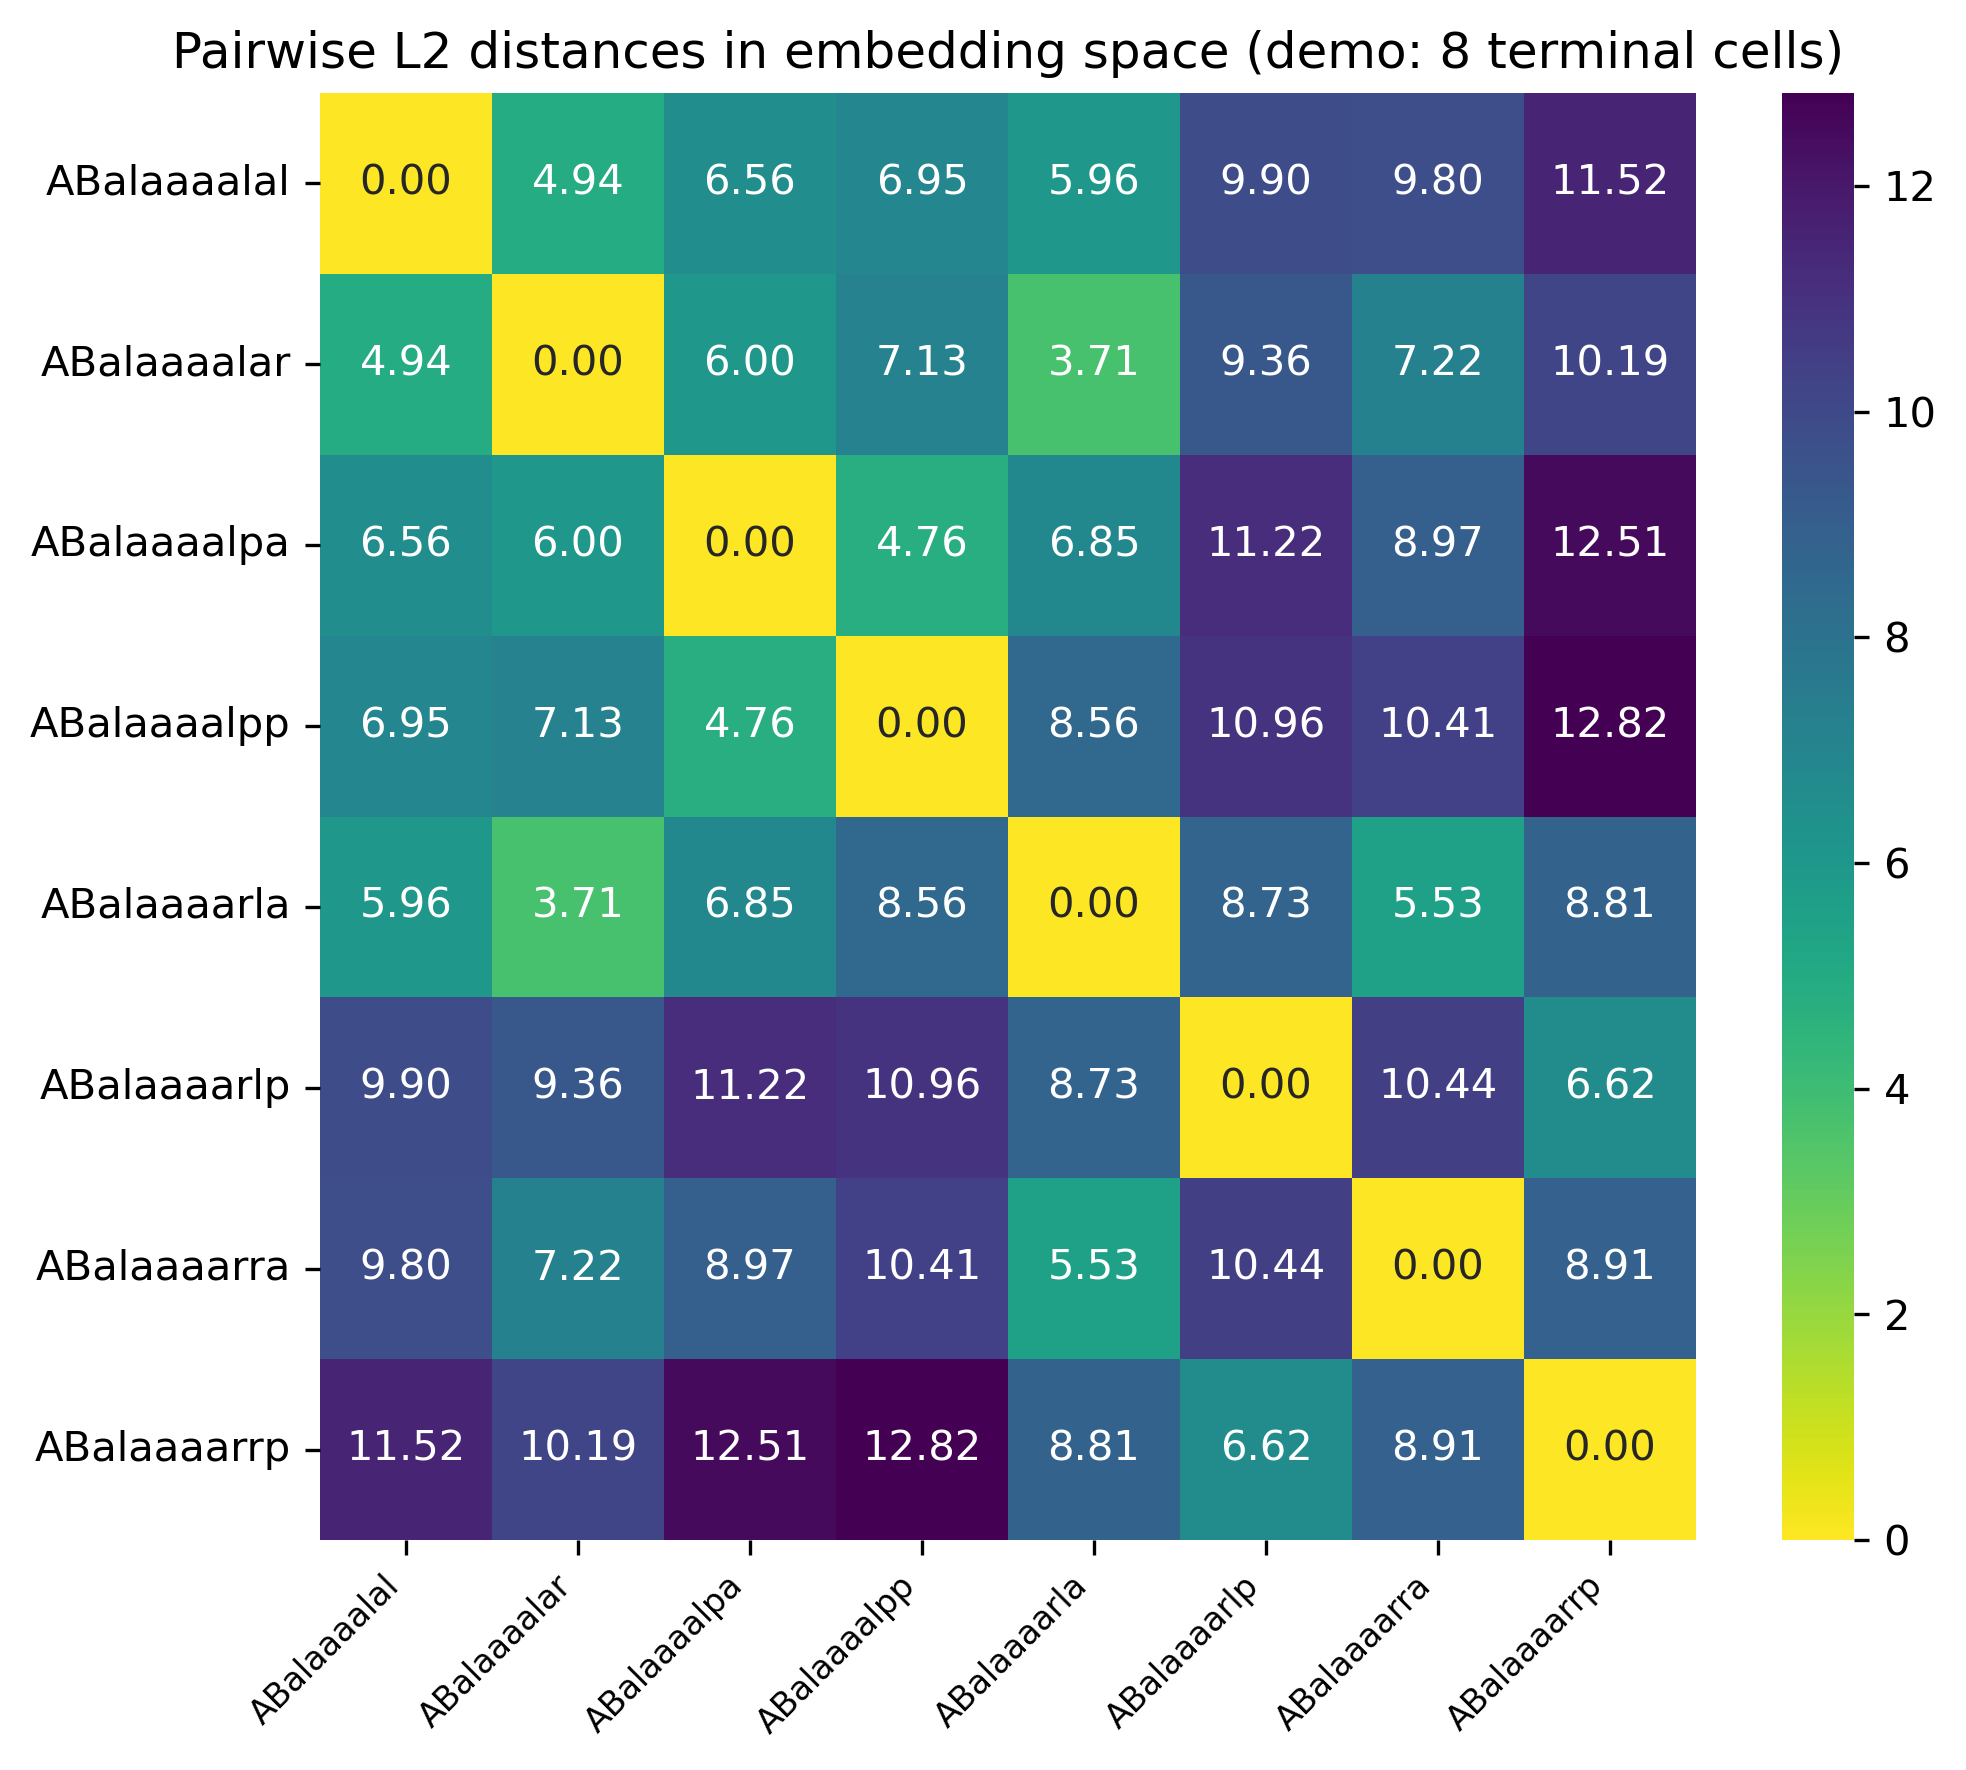


To compute all pairwise distances:
  dist_all = cdist(embeddings, embeddings, metric='euclidean')  # (1204, 1204)
  dist_cosine = cdist(embeddings, embeddings, metric='cosine')

Embedding array saved as `embeddings`; cell names as `cell_names`.


In [38]:

# ─── Embeddings for downstream distance analysis ─────────────────────────────
#
# The 32-dim penultimate-layer embedding captures the learned protein signature
# of each cell. Use it to compute pairwise distances between any sample pairs.
#
# Properties:
#   • Trained with soft-label supervision → intermediate nodes land between
#     their descendant terminal nodes in embedding space.
#   • Weighted training → distances among terminal nodes are most reliable.
#   • L2 or cosine distance both work; cosine is scale-invariant.

model_final.eval()
with torch.no_grad():
    _, embeddings_t = model_final(X_sel_t.to(device))
embeddings = embeddings_t.cpu().numpy()        # (1204, 32)
cell_names = np.array([map_names(n) for n in protein_exp_zscore.columns])

print(f"Embedding matrix: {embeddings.shape}  (n_cells × embed_dim)")
print(f"Cell names: {cell_names[:5]} ...")

# ── PCA visualisation ────────────────────────────────────────────
pca     = PCA(n_components=2)
emb_2d  = pca.fit_transform(embeddings)
ct_idx  = y.argmax(axis=1)          # dominant cell-type index per sample

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hard-label nodes coloured by cell type
ax = axes[0]
for i, ct in enumerate(cell_types):
    mask_ct = (ct_idx == i) & terminal_mask
    if mask_ct.sum() > 0:
        ax.scatter(emb_2d[mask_ct, 0], emb_2d[mask_ct, 1],
                   label=ct, s=18, alpha=0.8)
ax.set_title('PCA of embeddings – hard-label (terminal) cells')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=1.5)

# All cells: soft nodes in grey, hard nodes coloured
ax = axes[1]
ax.scatter(emb_2d[~terminal_mask, 0], emb_2d[~terminal_mask, 1],
           c='lightgray', s=6, alpha=0.3, label='intermediate (soft)')
scatter = ax.scatter(emb_2d[terminal_mask, 0], emb_2d[terminal_mask, 1],
                     c=ct_idx[terminal_mask], cmap='tab20', s=18, alpha=0.85,
                     label='terminal (hard)')
ax.set_title('PCA – all cells (soft nodes greyed out)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Example: pairwise L2 distances among a handful of terminal cells ─────────
from scipy.spatial.distance import cdist

# Pick first 8 terminal cells as a demo
demo_idx   = np.where(terminal_mask)[0][:8]
demo_names = cell_names[demo_idx]
demo_emb   = embeddings[demo_idx]

dist_mat = cdist(demo_emb, demo_emb, metric='euclidean')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='viridis_r',
            xticklabels=demo_names, yticklabels=demo_names, ax=ax)
ax.set_title('Pairwise L2 distances in embedding space (demo: 8 terminal cells)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTo compute all pairwise distances:")
print("  dist_all = cdist(embeddings, embeddings, metric='euclidean')  # (1204, 1204)")
print("  dist_cosine = cdist(embeddings, embeddings, metric='cosine')")
print("\nEmbedding array saved as `embeddings`; cell names as `cell_names`.")


Total terminal-sibling pairs in data: 209
  Same cell type : 105
  Diff cell type : 104

Same-type sibling distance:  mean=3.515  median=3.367  std=1.454
Diff-type sibling distance:  mean=5.134  median=4.785  std=2.018

Mann-Whitney U (same < diff): U=2719, p=1.82e-10
KS test (distributions differ): D=0.397, p=6.06e-08


/tmp/ipykernel_26755/3700415259.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([same_dists, diff_dists], labels=['Same type', 'Diff type'],
/tmp/ipykernel_26755/3700415259.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([same_dists, diff_dists], labels=['Same type', 'Diff type'],


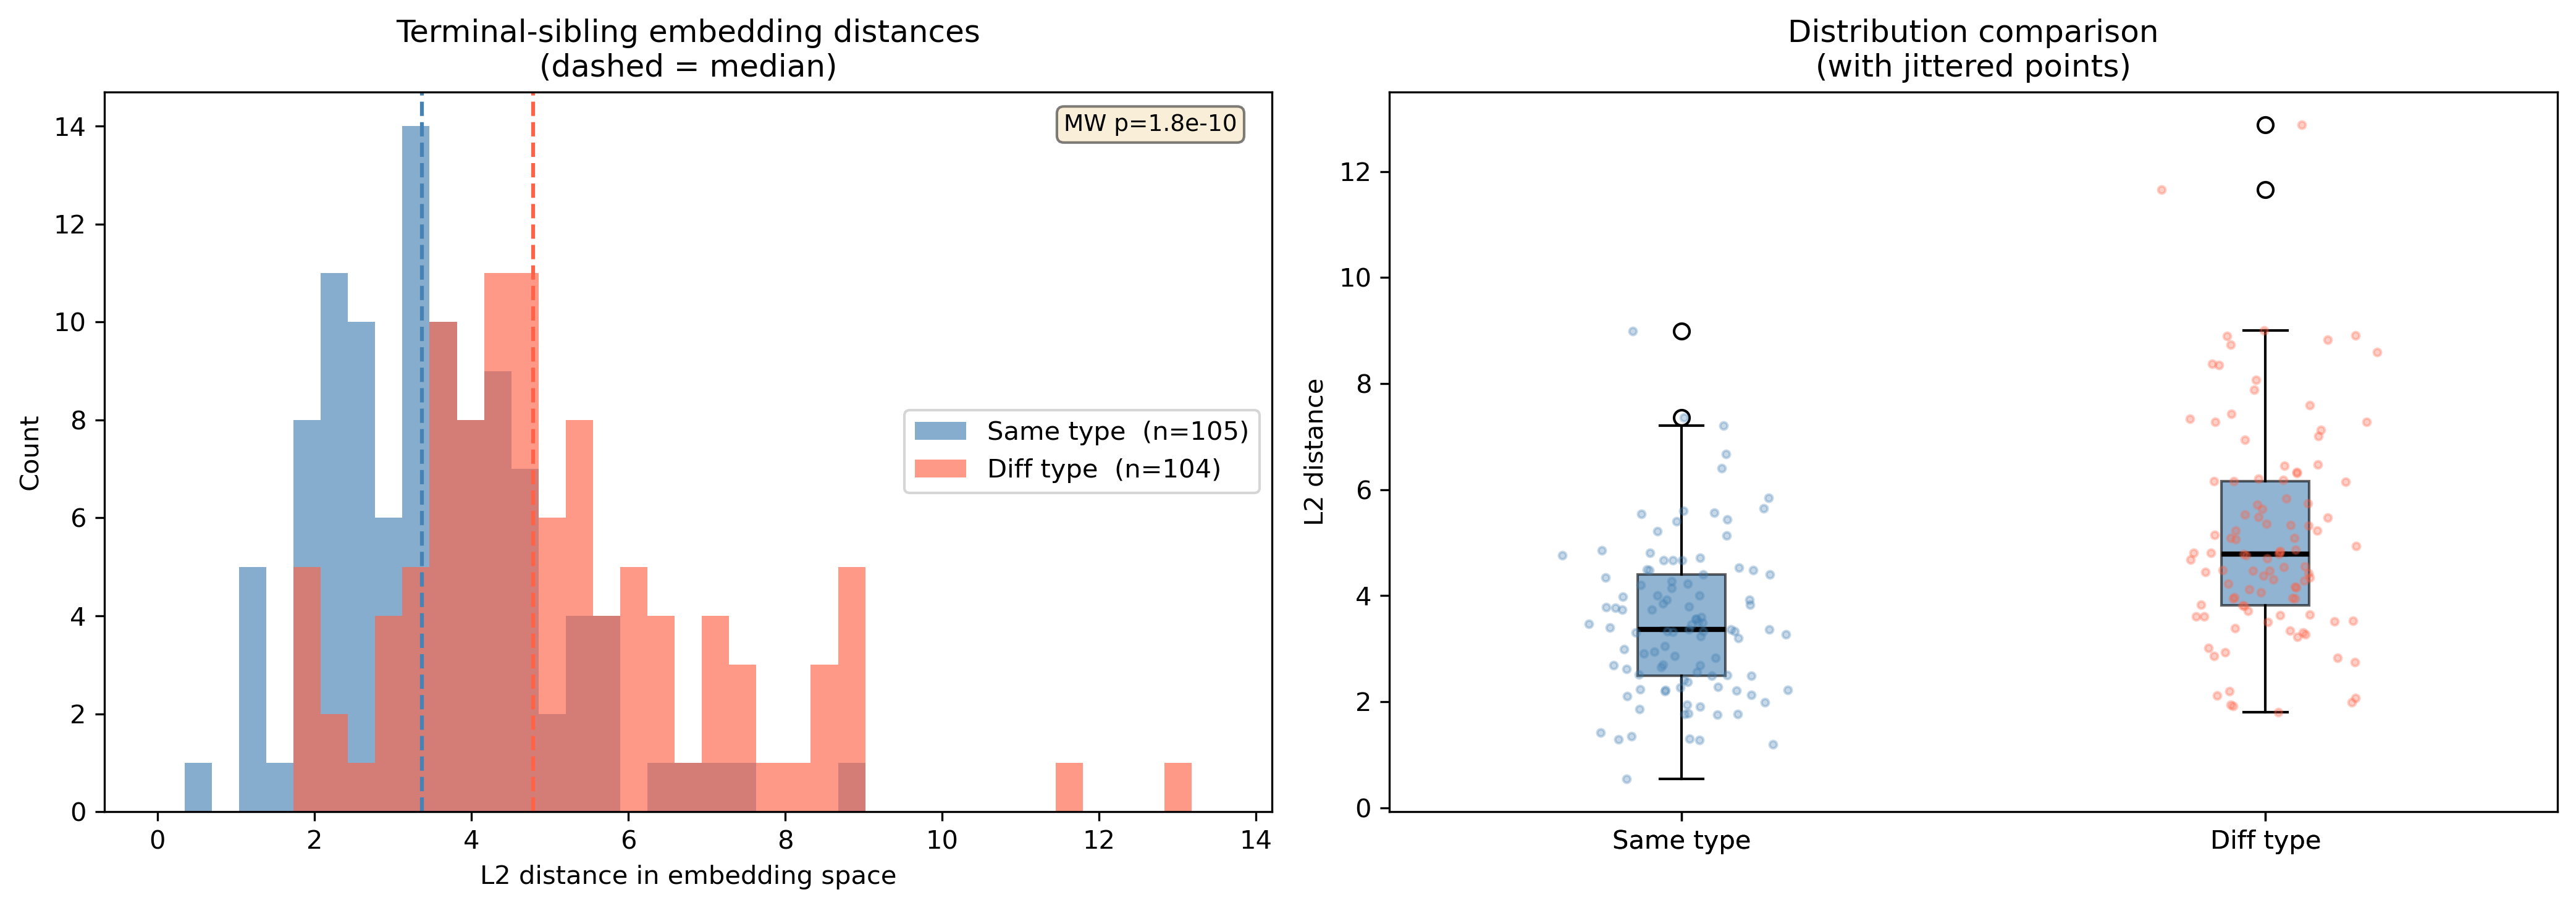


Same-type sibling distances by cell type:
  Type                              n    mean   median
  ----------------------------------------------------
  repro                             1   0.541    0.541
  socket                            1   1.759    1.759
  sheath                            2   2.716    2.716
  valve                             2   2.762    2.762
  other                             2   2.776    2.776
  hypoderm                         17   3.232    2.557
  muscle                           38   3.483    3.364
  neuron                           42   3.880    3.788


In [39]:

# ─── Sanity check: embedding distance for terminal siblings ──────────────────
#
# Hypothesis: same-type sibling pairs should have SMALLER embedding distance
# than different-type sibling pairs, because the classifier was trained to
# separate cell types.
#
# "Terminal siblings" = two terminal nodes that share the same direct parent.

# ── 1. Build parent→children map from the lineage tree ────────────────────────
children_dict_lin = defaultdict(list)   # parent_name → [child_names]
parent_dict_lin   = {}                  # child_name  → parent_name

def build_family(node, parent_name=None):
    name = map_names(node["did"])
    if parent_name is not None:
        parent_dict_lin[name] = parent_name
        children_dict_lin[parent_name].append(name)
    for child in node.get("children", []):
        build_family(child, name)

build_family(lineage_data)

# ── 2. Collect terminal-sibling pairs that are in the protein_exp data ─────────
# cell_names is the array of mapped cell names from protein_exp columns
cell_name_to_idx = {name: i for i, name in enumerate(cell_names)}
terminal_set     = set(cell_names[terminal_mask])   # terminal nodes present in data

sibling_pairs = []   # list of (nameA, nameB, same_type: bool)

for parent, children in children_dict_lin.items():
    term_children = [c for c in children if c in terminal_set]
    # All pairs among terminal children of this parent
    for i in range(len(term_children)):
        for j in range(i + 1, len(term_children)):
            a, b = term_children[i], term_children[j]
            type_a = cell_type_dict.get(a)
            type_b = cell_type_dict.get(b)
            if type_a is None or type_b is None:
                continue
            sibling_pairs.append((a, b, type_a == type_b))

same_pairs = [(a, b) for a, b, s in sibling_pairs if     s]
diff_pairs = [(a, b) for a, b, s in sibling_pairs if not s]
print(f"Total terminal-sibling pairs in data: {len(sibling_pairs)}")
print(f"  Same cell type : {len(same_pairs)}")
print(f"  Diff cell type : {len(diff_pairs)}")

# ── 3. Compute embedding distances ────────────────────────────────────────────
def pair_distance(a, b):
    ia, ib = cell_name_to_idx[a], cell_name_to_idx[b]
    return float(np.linalg.norm(embeddings[ia] - embeddings[ib]))

same_dists = np.array([pair_distance(a, b) for a, b in same_pairs])
diff_dists = np.array([pair_distance(a, b) for a, b in diff_pairs])

print(f"\nSame-type sibling distance:  mean={same_dists.mean():.3f}  median={np.median(same_dists):.3f}  std={same_dists.std():.3f}")
print(f"Diff-type sibling distance:  mean={diff_dists.mean():.3f}  median={np.median(diff_dists):.3f}  std={diff_dists.std():.3f}")

# Mann-Whitney U test (non-parametric, no normality assumption)
from scipy.stats import mannwhitneyu, ks_2samp
u_stat, p_mw = mannwhitneyu(same_dists, diff_dists, alternative='less')
ks_stat, p_ks = ks_2samp(same_dists, diff_dists)
print(f"\nMann-Whitney U (same < diff): U={u_stat:.0f}, p={p_mw:.2e}")
print(f"KS test (distributions differ): D={ks_stat:.3f}, p={p_ks:.2e}")

# ── 4. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histograms
ax = axes[0]
bins = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 40)
ax.hist(same_dists, bins=bins, alpha=0.65, color='steelblue',  label=f'Same type  (n={len(same_dists)})')
ax.hist(diff_dists, bins=bins, alpha=0.65, color='tomato',     label=f'Diff type  (n={len(diff_dists)})')
ax.axvline(np.median(same_dists), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(np.median(diff_dists), color='tomato',    linestyle='--', linewidth=1.5)
ax.set_xlabel('L2 distance in embedding space')
ax.set_ylabel('Count')
ax.set_title('Terminal-sibling embedding distances\n(dashed = median)')
ax.legend()
ax.text(0.97, 0.97, f'MW p={p_mw:.1e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot
ax = axes[1]
ax.boxplot([same_dists, diff_dists], labels=['Same type', 'Diff type'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='black', linewidth=2))
bp = ax.boxplot([same_dists, diff_dists], labels=['Same type', 'Diff type'],
                patch_artist=True, notch=True,
                boxprops=dict(alpha=0),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(alpha=0),
                capprops=dict(alpha=0),
                flierprops=dict(alpha=0))
# Jitter overlay
jitter = 0.08
np.random.seed(0)
ax.scatter(np.random.normal(1, jitter, len(same_dists)), same_dists,
           color='steelblue', alpha=0.3, s=8, zorder=3)
ax.scatter(np.random.normal(2, jitter, len(diff_dists)), diff_dists,
           color='tomato',    alpha=0.3, s=8, zorder=3)
ax.set_ylabel('L2 distance')
ax.set_title('Distribution comparison\n(with jittered points)')

plt.tight_layout()
plt.show()

# ── 5. Per-type breakdown for same-type pairs ─────────────────────────────────
type_pair_dists = defaultdict(list)
for a, b, same in sibling_pairs:
    if same:
        t = cell_type_dict[a]
        type_pair_dists[t].append(pair_distance(a, b))

print("\nSame-type sibling distances by cell type:")
print(f"  {'Type':30s}  {'n':>3}  {'mean':>6}  {'median':>7}")
print("  " + "-" * 52)
for t, dists in sorted(type_pair_dists.items(), key=lambda x: np.mean(x[1])):
    print(f"  {t:30s}  {len(dists):3d}  {np.mean(dists):6.3f}  {np.median(dists):7.3f}")


Original 15-feature space:
  Same-type sibling distance: mean=1.877  median=1.715  std=0.905
  Diff-type sibling distance: mean=2.513  median=2.412  std=1.021
  Mann-Whitney U (same < diff): U=3363, p=8.10e-07
  KS test (distributions differ): D=0.330, p=1.58e-05
  Median ratio (diff/same): 1.406
  Cohen's d: 0.657
  AUC-like separation: 0.692


,space,same_median,diff_median,median_ratio,cohen_d,auc_like,mw_pvalue
0,Selected 15 features,1.7151,2.4115,1.4060,0.6568,0.692,0.0
1,32D embedding,3.3671,4.7850,1.4211,0.9166,0.751,0.0


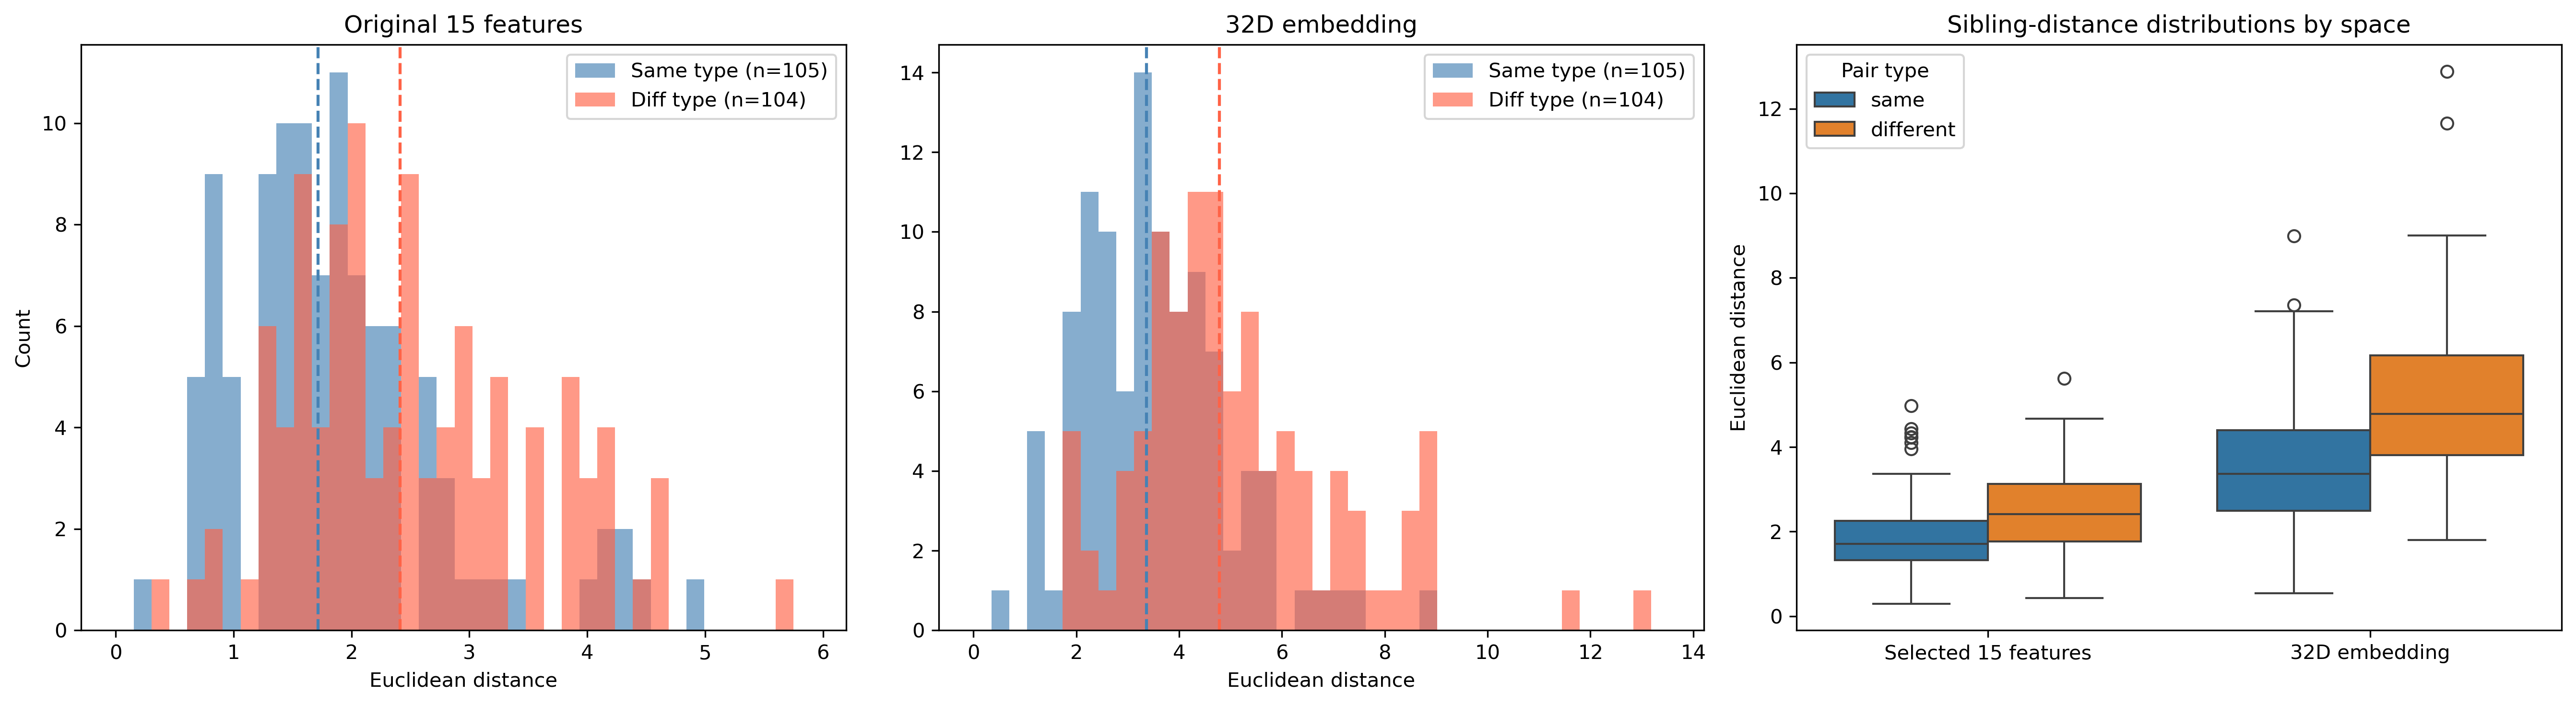


Same-type sibling distances by cell type in the original 15-feature space:
  Type                              n    mean   median
  ----------------------------------------------------
  repro                             1   0.297    0.297
  valve                             2   1.232    1.232
  neuron                           42   1.783    1.563
  muscle                           38   1.863    1.723
  hypoderm                         17   2.102    1.996
  socket                            1   2.130    2.130
  other                             2   2.245    2.245
  sheath                            2   3.133    3.133

Interpretation: the 32D embedding appears to sharpen sibling-type separation beyond what is already present in the raw 15 selected features.


In [40]:
# ─── Sanity check: sibling distances in the original selected-feature space ─────
##
## Question: do the original 15 selected protein features already separate
## same-type vs different-type terminal siblings in a way similar to the 32D
## learned embedding?
##
## We reuse the same sibling pairs from the previous cell and compare Euclidean
## distances in both spaces.

from scipy.stats import mannwhitneyu, ks_2samp
def pair_distance_in_space(a, b, representation, name_to_idx):
    ia, ib = name_to_idx[a], name_to_idx[b]
    return float(np.linalg.norm(representation[ia] - representation[ib]))

selected_feature_repr = X_sel
selected_same_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in same_pairs
])
selected_diff_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in diff_pairs
])

u_feat, p_feat = mannwhitneyu(selected_same_dists, selected_diff_dists, alternative='less')
ks_feat, p_ks_feat = ks_2samp(selected_same_dists, selected_diff_dists)

def separation_summary(same_dists, diff_dists, u_stat):
    n_same = len(same_dists)
    n_diff = len(diff_dists)
    pooled_std = np.sqrt(
        ((n_same - 1) * same_dists.std(ddof=1) ** 2 + (n_diff - 1) * diff_dists.std(ddof=1) ** 2)
        / (n_same + n_diff - 2)
    )
    cohen_d = (diff_dists.mean() - same_dists.mean()) / pooled_std
    auc = 1.0 - (u_stat / (n_same * n_diff))
    return {
        'same_mean': same_dists.mean(),
        'same_median': np.median(same_dists),
        'diff_mean': diff_dists.mean(),
        'diff_median': np.median(diff_dists),
        'median_ratio': np.median(diff_dists) / np.median(same_dists),
        'cohen_d': cohen_d,
        'auc_like': auc,
    }

embedding_summary = separation_summary(same_dists, diff_dists, u_stat)
feature_summary = separation_summary(selected_same_dists, selected_diff_dists, u_feat)

print('Original 15-feature space:')
print(f"  Same-type sibling distance: mean={feature_summary['same_mean']:.3f}  median={feature_summary['same_median']:.3f}  std={selected_same_dists.std():.3f}")
print(f"  Diff-type sibling distance: mean={feature_summary['diff_mean']:.3f}  median={feature_summary['diff_median']:.3f}  std={selected_diff_dists.std():.3f}")
print(f"  Mann-Whitney U (same < diff): U={u_feat:.0f}, p={p_feat:.2e}")
print(f"  KS test (distributions differ): D={ks_feat:.3f}, p={p_ks_feat:.2e}")
print(f"  Median ratio (diff/same): {feature_summary['median_ratio']:.3f}")
print(f"  Cohen's d: {feature_summary['cohen_d']:.3f}")
print(f"  AUC-like separation: {feature_summary['auc_like']:.3f}")

comparison_df = pd.DataFrame(
    [
        {
            'space': 'Selected 15 features',
            'same_median': feature_summary['same_median'],
            'diff_median': feature_summary['diff_median'],
            'median_ratio': feature_summary['median_ratio'],
            'cohen_d': feature_summary['cohen_d'],
            'auc_like': feature_summary['auc_like'],
            'mw_pvalue': p_feat,
        },
        {
            'space': '32D embedding',
            'same_median': embedding_summary['same_median'],
            'diff_median': embedding_summary['diff_median'],
            'median_ratio': embedding_summary['median_ratio'],
            'cohen_d': embedding_summary['cohen_d'],
            'auc_like': embedding_summary['auc_like'],
            'mw_pvalue': p_mw,
        },
    ]
)
display(comparison_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins_feat = np.linspace(
    0, max(selected_same_dists.max(), selected_diff_dists.max()) * 1.05, 40
)
axes[0].hist(selected_same_dists, bins=bins_feat, alpha=0.65, color='steelblue',
             label=f'Same type (n={len(selected_same_dists)})')
axes[0].hist(selected_diff_dists, bins=bins_feat, alpha=0.65, color='tomato',
             label=f'Diff type (n={len(selected_diff_dists)})')
axes[0].axvline(np.median(selected_same_dists), color='steelblue', linestyle='--', linewidth=1.5)
axes[0].axvline(np.median(selected_diff_dists), color='tomato', linestyle='--', linewidth=1.5)
axes[0].set_title('Original 15 features')
axes[0].set_xlabel('Euclidean distance')
axes[0].set_ylabel('Count')
axes[0].legend()

bins_emb = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 40)
axes[1].hist(same_dists, bins=bins_emb, alpha=0.65, color='steelblue',
             label=f'Same type (n={len(same_dists)})')
axes[1].hist(diff_dists, bins=bins_emb, alpha=0.65, color='tomato',
             label=f'Diff type (n={len(diff_dists)})')
axes[1].axvline(np.median(same_dists), color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axvline(np.median(diff_dists), color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_title('32D embedding')
axes[1].set_xlabel('Euclidean distance')
axes[1].legend()

comparison_long = pd.DataFrame({
    'distance': np.concatenate([selected_same_dists, selected_diff_dists, same_dists, diff_dists]),
    'pair_type': (['same'] * len(selected_same_dists) + ['different'] * len(selected_diff_dists) +
                  ['same'] * len(same_dists) + ['different'] * len(diff_dists)),
    'space': (['Selected 15 features'] * (len(selected_same_dists) + len(selected_diff_dists)) +
              ['32D embedding'] * (len(same_dists) + len(diff_dists)))
})
sns.boxplot(data=comparison_long, x='space', y='distance', hue='pair_type', ax=axes[2])
axes[2].set_title('Sibling-distance distributions by space')
axes[2].set_xlabel('')
axes[2].set_ylabel('Euclidean distance')
axes[2].legend(title='Pair type')

plt.tight_layout()
plt.show()

feature_type_pair_dists = defaultdict(list)
for a, b, same in sibling_pairs:
    if same:
        t = cell_type_dict[a]
        feature_type_pair_dists[t].append(
            pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
        )

print('\nSame-type sibling distances by cell type in the original 15-feature space:')
print(f"  {'Type':30s}  {'n':>3}  {'mean':>6}  {'median':>7}")
print('  ' + '-' * 52)
for t, dists in sorted(feature_type_pair_dists.items(), key=lambda x: np.mean(x[1])):
    print(f"  {t:30s}  {len(dists):3d}  {np.mean(dists):6.3f}  {np.median(dists):7.3f}")

if feature_summary['auc_like'] >= embedding_summary['auc_like'] - 0.02:
    print('\nInterpretation: the original 15-feature space preserves most of the sibling-type separation signal seen in the learned embedding.')
else:
    print('\nInterpretation: the 32D embedding appears to sharpen sibling-type separation beyond what is already present in the raw 15 selected features.')

In [41]:
# Save embeddings (32D) and selected protein names (trim reporter) to disk
import os
import pandas as pd

out_dir = './data/protein/aggregated_all/'
os.makedirs(out_dir, exist_ok=True)

# embeddings: numpy array (n_cells, 32), cell_names: array of cell names
emb_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
emb_df = pd.DataFrame(embeddings, index=cell_names, columns=emb_cols)
emb_df.index.name = 'cell_name'
emb_df.to_csv(os.path.join(out_dir, 'embeddings_32d.csv'))

# top_features: array of feature names like 'protein_reporter' -> trim reporter by rsplit
trimmed_proteins = [f.rsplit('_', 1)[0] for f in top_features]
# Save as TSV, one protein per line, no header
pd.Series(trimmed_proteins).to_csv(os.path.join(out_dir, 'nn_selected_proteins.tsv'), sep='\t', index=False, header=False)

print(f"Saved embeddings to {os.path.join(out_dir, 'embeddings_32d.csv')}")
print(f"Saved selected protein names to {os.path.join(out_dir, 'nn_selected_proteins.tsv')}")

Saved embeddings to ./data/protein/aggregated_all/embeddings_32d.csv
Saved selected protein names to ./data/protein/aggregated_all/nn_selected_proteins.tsv


In [23]:
tissue_specific_tfs = pd.read_csv('data/protein/aggregated_all/tissue_specific_tf.tsv', sep='\t', header=None, index_col=0).index.tolist()
tissue_specific_selected_proteins = list(set(tissue_specific_tfs).intersection(set(trimmed_proteins)))

In [33]:
# a new X_tissue_specific from the tissue_specific_selected_proteins
tissue_specific_indices = [i for i, f in enumerate(feature_names) if f.rsplit('_', 1)[0] in tissue_specific_selected_proteins]
X_tissue_specific = X[:, tissue_specific_indices]

In [34]:
selected_feature_repr = X_tissue_specific
selected_same_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in same_pairs
])
selected_diff_dists = np.array([
    pair_distance_in_space(a, b, selected_feature_repr, cell_name_to_idx)
    for a, b in diff_pairs
])

u_feat, p_feat = mannwhitneyu(selected_same_dists, selected_diff_dists, alternative='less')
ks_feat, p_ks_feat = ks_2samp(selected_same_dists, selected_diff_dists)
feature_summary = separation_summary(selected_same_dists, selected_diff_dists, u_feat)
print('Tissue-specific selected features:')
print(f"  Same-type sibling distance: mean={feature_summary['same_mean']:.3f}  median={feature_summary['same_median']:.3f}  std={selected_same_dists.std():.3f}")
print(f"  Diff-type sibling distance: mean={feature_summary['diff_mean']:.3f}  median={feature_summary['diff_median']:.3f}  std={selected_diff_dists.std():.3f}")
print(f"  Mann-Whitney U (same < diff): U={u_feat:.0f}, p={p_feat:.2e}")
print(f"  KS test (distributions differ): D={ks_feat:.3f}, p={p_ks_feat:.2e}")
print(f"  Median ratio (diff/same): {feature_summary['median_ratio']:.3f}")
print(f"  Cohen's d: {feature_summary['cohen_d']:.3f}")
print(f"  AUC-like separation: {feature_summary['auc_like']:.3f}")


Tissue-specific selected features:
  Same-type sibling distance: mean=0.608  median=0.457  std=0.638
  Diff-type sibling distance: mean=1.303  median=1.113  std=0.929
  Mann-Whitney U (same < diff): U=2691, p=1.14e-10
  KS test (distributions differ): D=0.370, p=5.42e-07
  Median ratio (diff/same): 2.434
  Cohen's d: 0.868
  AUC-like separation: 0.754
